# SIH perception: SalsaNext + CUDA Grid Engine (v2)

One notebook for the whole path from LiDAR scan to 2.5D grid:

1. **SalsaNext** semantic segmentation, with the review fixes applied:
   no double softmax, deterministic range projection, empty pixels fed as 0 (as in training),
   KNN post-processing, checkpoint key check, optional FP16 inference (`USE_FP16`).
2. **Grid Engine v2 in C++/CUDA**: labels and confidences stay on the GPU and go straight in.
   5 / 10 / 20 / 40 cm cells, SalsaNext class IDs (1–19), no points lost at band edges,
   exact statistics for split and merged cells, fixed physical terrain limits,
   and no merging within 10 m so the near field stays at 5 cm.
3. **Checks**: CUDA output vs the NumPy reference, latency benchmark (target: Grid Engine < 30 ms),
   accuracy vs SemanticKITTI ground truth, and per-frame export for the dashboard.

**Before running:** Settings → Accelerator → **GPU T4 x2**. Attach the velodyne scans,
the sequence 08 `labels`, and the SalsaNext pretrained weights as input datasets.

## 1. Setup

In [1]:
import os, sys, glob, time, math
import numpy as np
import torch

if not os.path.exists('/kaggle/working/SalsaNext'):
    !git clone -q https://github.com/tiagoCortinhal/SalsaNext.git /kaggle/working/SalsaNext
# Python 3.12 compatibility fixes for SalsaNext
!sed -i 's/import imp//g' /kaggle/working/SalsaNext/train/tasks/semantic/modules/SalsaNext.py
!sed -i 's/import __init__ as booger//g' /kaggle/working/SalsaNext/train/tasks/semantic/modules/SalsaNext.py
!pip install -q ninja nvidia-ml-py

from torch.utils.cpp_extension import CUDA_HOME
assert torch.cuda.is_available(), "No GPU found: set Accelerator to 'GPU T4 x2'"
cap = torch.cuda.get_device_capability(0)
os.environ['TORCH_CUDA_ARCH_LIST'] = f"{cap[0]}.{cap[1]}"   # build only for this GPU (faster compile)
torch.backends.cudnn.benchmark = True

print("GPU       :", torch.cuda.get_device_name(0), f"(sm_{cap[0]}{cap[1]})")
print("torch     :", torch.__version__, "| built for CUDA", torch.version.cuda)
print("CUDA_HOME :", CUDA_HOME)
if CUDA_HOME:
    !{CUDA_HOME}/bin/nvcc --version | tail -n 2
else:
    print("No CUDA toolkit found: the C++/CUDA extension cannot be compiled on this image.")

GPU       : Tesla T4 (sm_75)
torch     : 2.10.0+cu128 | built for CUDA 12.8
CUDA_HOME : /usr/local/cuda
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


## 2. Grid Engine v2 source files
These cells write the package to `/kaggle/working/grid_engine_v2`.

In [2]:
os.makedirs('/kaggle/working/grid_engine_v2/csrc', exist_ok=True)

In [3]:
%%writefile /kaggle/working/grid_engine_v2/__init__.py
"""Grid Engine v2: variable-resolution 2.5D semantic grid (NumPy reference + CUDA)."""
from . import config
from .reference import run_reference, to_structured, grid_config_from_bounds

Writing /kaggle/working/grid_engine_v2/__init__.py


In [4]:
%%writefile /kaggle/working/grid_engine_v2/config.py
# -*- coding: utf-8 -*-
"""
Grid Engine v2 -- Configuration
===============================
Single source of truth for the NumPy reference and the CUDA engine.

Changes from v1:
  * Class IDs follow SalsaNext / SemanticKITTI learning_map: 0 = unlabeled,
    1 = car ... 19 = traffic-sign. Unlabeled points are dropped before gridding.
  * Cell sizes double at every level (5 / 10 / 20 / 40 cm), so the quadtree
    nests exactly and split/merge always land on a listed size.
  * The cell size is chosen per 40 cm tile (by tile-centre distance), not per
    point, so cells never overlap and no points are lost at band edges.
  * Terrain complexity uses fixed physical limits instead of per-frame maxima.
  * No merging within 10 m, so the whole near field stays at 5 cm.
"""

import numpy as np

# ── Cell sizes / quadtree levels ───────────────────────────────
# Level 3 is the finest. size(L) = FINEST_CELL_M * 2 ** (MAX_LEVEL - L)
MAX_LEVEL = 3
FINEST_CELL_M = 0.05
TILE_M = FINEST_CELL_M * 2 ** MAX_LEVEL          # 0.40 m, the level-0 cell
LEVEL_SIZE_M = {L: FINEST_CELL_M * 2 ** (MAX_LEVEL - L) for L in range(MAX_LEVEL + 1)}

# ── Distance bands (tile-centre distance in the XY plane) ─────
# [0, 10) m -> level 3 (5 cm), [10, 30) -> 2 (10 cm), [30, 60) -> 1 (20 cm),
# >= 60 m -> 0 (40 cm)
BAND_EDGE_L3_M = 10.0
BAND_EDGE_L2_M = 30.0
BAND_EDGE_L1_M = 60.0

# ── Semantic classes (SalsaNext numbering) ─────────────────────
LABEL_NAMES = {
    0: "unlabeled",
    1: "car",
    2: "bicycle",
    3: "motorcycle",
    4: "truck",
    5: "other-vehicle",
    6: "person",
    7: "bicyclist",
    8: "motorcyclist",
    9: "road",
    10: "parking",
    11: "sidewalk",
    12: "other-ground",
    13: "building",
    14: "fence",
    15: "vegetation",
    16: "trunk",
    17: "terrain",
    18: "pole",
    19: "traffic-sign",
}
N_CLASSES = len(LABEL_NAMES)        # 20
UNLABELED = 0

CLASS_COLORS = {
    0: "#000000",
    1: "#ff0000", 2: "#ff8000", 3: "#ff8000", 4: "#800000", 5: "#800000",
    6: "#0000ff", 7: "#0000ff", 8: "#0000ff",
    9: "#808080", 10: "#606060", 11: "#a0a0a0", 12: "#c0c0c0",
    13: "#ffd700", 14: "#8b4513", 15: "#008000", 16: "#8b4513",
    17: "#90ee90", 18: "#d3d3d3", 19: "#ff00ff",
}

SEMANTIC_PRIORITY = {
    0: 5,
    1: 5, 2: 5, 3: 5, 4: 5, 5: 5,      # vehicles
    6: 5, 7: 5, 8: 5,                  # people
    9: 1, 10: 1, 11: 1, 12: 1,         # ground
    13: 4, 14: 4,                      # building, fence
    15: 2,                             # vegetation
    16: 4,                             # trunk
    17: 1,                             # terrain
    18: 4, 19: 4,                      # pole, traffic-sign
}

TRAVERSABILITY_WEIGHT = {
    0: 0.00,
    1: 0.10, 2: 0.10, 3: 0.10, 4: 0.10, 5: 0.10,
    6: 0.05, 7: 0.05, 8: 0.05,
    9: 0.95, 10: 0.90, 11: 0.85, 12: 0.70,
    13: 0.05, 14: 0.05,
    15: 0.40,
    16: 0.05,
    17: 0.50,
    18: 0.05, 19: 0.05,
}

# ── Refinement parameters ──────────────────────────────────────
SPLIT_PRIORITY_THRESHOLD = 4
MERGE_PRIORITY_THRESHOLD = 2
SPLIT_MIN_POINTS = 2
# No merging for parent cells whose 40 cm tile centre is closer than this, so
# the near field keeps its 5 cm cells. 0 disables the rule.
NO_MERGE_RADIUS_M = BAND_EDGE_L3_M

# ── Terrain complexity (fixed physical limits) ─────────────────
# complexity = W_RANGE * min(height_range / RANGE_LIMIT, 1)
#            + W_STD   * min(height_std   / STD_LIMIT,   1)
TERRAIN_RANGE_LIMIT_M = 0.30
TERRAIN_STD_LIMIT_M = 0.10
TERRAIN_W_RANGE = 0.6
TERRAIN_W_STD = 0.4
TRAV_TERRAIN_PENALTY = 0.5          # traversability *= 1 - 0.5 * complexity

# ── Grid bounds (informational, for the dashboard) ─────────────
BOUNDARY_PADDING_M = 1.0

# ── Final cell dtype (same schema as v1) ───────────────────────
FINAL_FIELDS = [
    ('x_min',                np.float64),
    ('x_max',                np.float64),
    ('y_min',                np.float64),
    ('y_max',                np.float64),
    ('x_center',             np.float64),
    ('y_center',             np.float64),
    ('resolution',           np.float64),
    ('level',                np.int32),
    ('elevation',            np.float64),
    ('min_height',           np.float64),
    ('max_height',           np.float64),
    ('elevation_variance',   np.float64),
    ('semantic_class',       np.int32),
    ('semantic_confidence',  np.float64),
    ('occupancy',            np.float64),
    ('terrain_complexity',   np.float64),
    ('traversability',       np.float64),
    ('point_count',          np.float64),
    ('semantic_priority',    np.int32),
    ('height_range',         np.float64),
]
FINAL_DTYPE = np.dtype(FINAL_FIELDS)
N_FINAL_FIELDS = len(FINAL_FIELDS)   # 20; column order of the engine's output matrix

# ── Lookup tables ──────────────────────────────────────────────
SEMANTIC_PRIORITY_LUT = np.array(
    [SEMANTIC_PRIORITY[i] for i in range(N_CLASSES)], dtype=np.int32)
TRAVERSABILITY_LUT = np.array(
    [TRAVERSABILITY_WEIGHT[i] for i in range(N_CLASSES)], dtype=np.float64)

# ── Cell key packing (shared by reference and CUDA) ────────────
# key = level << 44 | (ix + OFF) << 22 | (iy + OFF), ix/iy in level-L cell units
KEY_BITS = 22
KEY_OFF = 1 << (KEY_BITS - 1)           # +-2,097,151 cells (+-104 km at 5 cm)
KEY_MASK = (1 << KEY_BITS) - 1
LEVEL_SHIFT = 2 * KEY_BITS


def cuda_params():
    """Scalar parameters passed to the CUDA engine, in the order it expects."""
    return [
        float(FINEST_CELL_M), float(TILE_M),
        float(BAND_EDGE_L3_M), float(BAND_EDGE_L2_M), float(BAND_EDGE_L1_M),
        float(SPLIT_PRIORITY_THRESHOLD), float(SPLIT_MIN_POINTS),
        float(MERGE_PRIORITY_THRESHOLD),
        float(TERRAIN_RANGE_LIMIT_M), float(TERRAIN_STD_LIMIT_M),
        float(TERRAIN_W_RANGE), float(TERRAIN_W_STD), float(TRAV_TERRAIN_PENALTY),
        float(NO_MERGE_RADIUS_M),
    ]

Writing /kaggle/working/grid_engine_v2/config.py


In [5]:
%%writefile /kaggle/working/grid_engine_v2/reference.py
# -*- coding: utf-8 -*-
"""
Grid Engine v2 -- NumPy reference implementation
================================================
This is the specification the CUDA engine must reproduce. Every step mirrors
a CUDA kernel, including summation order, so results match bit for bit:
sums use np.bincount (sequential, in sorted point order), sorts are stable,
and all geometry is float64.

Pipeline
  1. Drop unlabeled points (class 0).
  2. Per point: finest-cell index (5 cm), 40 cm tile, tile-centre distance ->
     base level. Every point in a tile uses the same cell size.
  3. Group points by base-level cell -> stage-1 leaf cells.
  4. Split: leaves with priority >= 4, level < 3 and >= 2 points are replaced
     by their non-empty quadrant children (one level finer), recomputed from
     the points themselves.
  5. Merge (single pass): a parent whose children are all leaves, all the
     same class and all priority <= 2 becomes one leaf with exact combined
     statistics. Parents whose tile centre is within NO_MERGE_RADIUS_M never
     merge, so the near field keeps its 5 cm cells.
  6. Final per-cell fields (FINAL_DTYPE order).
"""

import numpy as np
from . import config as C

_NC = C.N_CLASSES


# ── key helpers ────────────────────────────────────────────────
def pack_key(level, ix, iy):
    return ((np.asarray(level, np.int64) << C.LEVEL_SHIFT)
            | ((np.asarray(ix, np.int64) + C.KEY_OFF) << C.KEY_BITS)
            | (np.asarray(iy, np.int64) + C.KEY_OFF))


def unpack_key(key):
    key = np.asarray(key, np.int64)
    level = key >> C.LEVEL_SHIFT
    ix = ((key >> C.KEY_BITS) & C.KEY_MASK) - C.KEY_OFF
    iy = (key & C.KEY_MASK) - C.KEY_OFF
    return level, ix, iy


def parent_key(key):
    """Parent cell key, or -1 for level-0 cells."""
    level, ix, iy = unpack_key(key)
    out = pack_key(np.maximum(level - 1, 0), ix >> 1, iy >> 1)
    return np.where(level > 0, out, -1)


# ── stage helpers ──────────────────────────────────────────────
def point_cells(xyz):
    """Finest-cell indices and base-level cell key for every point."""
    x = xyz[:, 0].astype(np.float64)
    y = xyz[:, 1].astype(np.float64)
    lim = C.KEY_OFF - 1
    i3x = np.clip(np.floor(x / C.FINEST_CELL_M).astype(np.int64), -lim, lim)
    i3y = np.clip(np.floor(y / C.FINEST_CELL_M).astype(np.int64), -lim, lim)

    tx = i3x >> C.MAX_LEVEL
    ty = i3y >> C.MAX_LEVEL
    cx = (tx.astype(np.float64) + 0.5) * C.TILE_M
    cy = (ty.astype(np.float64) + 0.5) * C.TILE_M
    r2 = cx * cx + cy * cy

    level = np.zeros(len(x), dtype=np.int64)
    level[r2 < C.BAND_EDGE_L1_M * C.BAND_EDGE_L1_M] = 1
    level[r2 < C.BAND_EDGE_L2_M * C.BAND_EDGE_L2_M] = 2
    level[r2 < C.BAND_EDGE_L3_M * C.BAND_EDGE_L3_M] = 3
    sh = C.MAX_LEVEL - level
    key = pack_key(level, i3x >> sh, i3y >> sh)
    return i3x, i3y, key


def near_field(key):
    """True for cells whose 40 cm tile centre is within NO_MERGE_RADIUS_M."""
    level, ix, iy = unpack_key(key)
    cx = ((ix >> level).astype(np.float64) + 0.5) * C.TILE_M
    cy = ((iy >> level).astype(np.float64) + 0.5) * C.TILE_M
    return cx * cx + cy * cy < C.NO_MERGE_RADIUS_M * C.NO_MERGE_RADIUS_M


def reduce_sorted(sorted_keys, perm, z, labels, conf):
    """Per-cell statistics for points already sorted by cell key.

    Returns (cells, seg) where seg[j] is the cell of sorted point j.
    """
    n = len(sorted_keys)
    starts = np.r_[0, np.flatnonzero(sorted_keys[1:] != sorted_keys[:-1]) + 1]
    counts = np.diff(np.r_[starts, n])
    ns = len(starts)
    seg = np.repeat(np.arange(ns, dtype=np.int64), counts)

    zz = z[perm].astype(np.float64)
    s1 = np.bincount(seg, weights=zz, minlength=ns)
    s2 = np.bincount(seg, weights=zz * zz, minlength=ns)
    zmin = np.minimum.reduceat(zz, starts)
    zmax = np.maximum.reduceat(zz, starts)

    sc = np.bincount(seg * _NC + labels[perm].astype(np.int64),
                     weights=conf[perm].astype(np.float64),
                     minlength=ns * _NC).reshape(ns, _NC)
    cls = np.argmax(sc, axis=1).astype(np.int64)
    total = np.zeros(ns)
    for c in range(_NC):                  # sequential, like the CUDA loop
        total = total + sc[:, c]
    wscore = sc[np.arange(ns), cls]

    cells = dict(key=sorted_keys[starts].copy(), cnt=counts.astype(np.int64),
                 sum=s1, sumsq=s2, zmin=zmin, zmax=zmax,
                 cls=cls, wscore=wscore, total=total)
    return cells, seg


def _select(cells, idx):
    return {k: v[idx] for k, v in cells.items()}


def _concat(a, b):
    return {k: np.concatenate([a[k], b[k]]) for k in a}


def finalize(cells):
    """Per-cell output matrix, columns in FINAL_DTYPE order."""
    level, ix, iy = unpack_key(cells['key'])
    size = C.FINEST_CELL_M * np.exp2((C.MAX_LEVEL - level).astype(np.float64))
    x_min = ix.astype(np.float64) * size
    x_max = (ix + 1).astype(np.float64) * size
    y_min = iy.astype(np.float64) * size
    y_max = (iy + 1).astype(np.float64) * size

    cnt = cells['cnt'].astype(np.float64)
    mean = cells['sum'] / cnt
    var = np.maximum(cells['sumsq'] / cnt - mean * mean, 0.0)
    hr = cells['zmax'] - cells['zmin']
    std = np.sqrt(var)
    complexity = (C.TERRAIN_W_RANGE * np.minimum(hr / C.TERRAIN_RANGE_LIMIT_M, 1.0)
                  + C.TERRAIN_W_STD * np.minimum(std / C.TERRAIN_STD_LIMIT_M, 1.0))
    cls = cells['cls']
    trav = C.TRAVERSABILITY_LUT[cls] * (1.0 - C.TRAV_TERRAIN_PENALTY * complexity)
    trav = np.minimum(np.maximum(trav, 0.0), 1.0)
    total = cells['total']
    conf = np.where(total > 0, cells['wscore'] / np.where(total > 0, total, 1.0), 0.0)

    cols = [x_min, x_max, y_min, y_max,
            (x_min + x_max) * 0.5, (y_min + y_max) * 0.5,
            size, level.astype(np.float64),
            mean, cells['zmin'], cells['zmax'], var,
            cls.astype(np.float64), conf, np.ones_like(mean),
            complexity, trav, cnt,
            C.SEMANTIC_PRIORITY_LUT[cls].astype(np.float64), hr]
    return np.stack(cols, axis=1)


# ── public API ─────────────────────────────────────────────────
def run_reference(xyz, labels, conf):
    """Run the full v2 Grid Engine on CPU.

    xyz: (N, 3) float, labels: (N,) int in 0..19, conf: (N,) float.
    Returns (matrix, stats, bounds): matrix is (n_cells, 20) float64 in
    FINAL_DTYPE column order, sorted by cell key.
    """
    xyz = np.asarray(xyz)[:, :3]
    labels = np.asarray(labels).astype(np.int64)
    conf = np.asarray(conf)
    n_in = len(labels)
    if labels.size and (labels.min() < 0 or labels.max() >= _NC):
        raise ValueError(f"labels must be in 0..{_NC - 1}")

    keep = labels != C.UNLABELED
    xyz, labels, conf = xyz[keep], labels[keep], conf[keep]
    n = len(labels)
    stats = dict(n_points_in=n_in, n_points_used=n, n_unlabeled_dropped=n_in - n,
                 n_stage1_cells=0, n_splits=0, n_merges=0, n_final_cells=0)
    if n == 0:
        return np.zeros((0, C.N_FINAL_FIELDS)), stats, None

    bounds = np.array([xyz[:, 0].min(), xyz[:, 1].min(),
                       xyz[:, 0].max(), xyz[:, 1].max()], dtype=np.float64)
    z = xyz[:, 2]

    # Stage 1: base-level cells
    i3x, i3y, key0 = point_cells(xyz)
    order = np.argsort(key0, kind='stable')
    ks = key0[order]
    cells1, seg1 = reduce_sorted(ks, order, z, labels, conf)
    stats['n_stage1_cells'] = len(cells1['key'])

    # Stage 2: split high-priority cells into quadrant children
    level1 = cells1['key'] >> C.LEVEL_SHIFT
    split = ((C.SEMANTIC_PRIORITY_LUT[cells1['cls']] >= C.SPLIT_PRIORITY_THRESHOLD)
             & (level1 < C.MAX_LEVEL)
             & (cells1['cnt'] >= C.SPLIT_MIN_POINTS))
    n_splits = int(split.sum())
    stats['n_splits'] = n_splits
    if n_splits:
        pt_split = split[seg1]
        child_level = (ks >> C.LEVEL_SHIFT) + 1
        sh = np.maximum(C.MAX_LEVEL - child_level, 0)
        p = order
        child_key = pack_key(child_level, i3x[p] >> sh, i3y[p] >> sh)
        key1 = np.where(pt_split, child_key, ks)
        o2 = np.argsort(key1, kind='stable')
        cells2, _ = reduce_sorted(key1[o2], order[o2], z, labels, conf)
    else:
        cells2 = cells1

    # Stage 3: merge (single pass)
    n2 = len(cells2['key'])
    par2 = parent_key(cells2['key'])
    leaf_m = np.flatnonzero(par2 >= 0)
    mkey = par2[leaf_m]
    msrc = leaf_m.astype(np.int64)
    if n_splits:
        par_s = parent_key(cells1['key'][split])
        par_s = par_s[par_s >= 0]
        mkey = np.concatenate([mkey, par_s])
        msrc = np.concatenate([msrc, np.full(len(par_s), -1, np.int64)])

    removed = np.zeros(n2, dtype=bool)
    merged = None
    if len(mkey):
        mo = np.argsort(mkey, kind='stable')
        mks, msrc_s = mkey[mo], msrc[mo]
        gstart = np.r_[0, np.flatnonzero(mks[1:] != mks[:-1]) + 1]
        gcnt = np.diff(np.r_[gstart, len(mks)])
        ng = len(gstart)
        gid = np.repeat(np.arange(ng), gcnt)

        is_int = msrc_s < 0
        src = np.where(is_int, 0, msrc_s)
        m_cls = cells2['cls'][src]
        m_pri = C.SEMANTIC_PRIORITY_LUT[m_cls]
        has_int = np.maximum.reduceat(is_int.astype(np.int8), gstart) > 0
        pri_ok = np.maximum.reduceat(np.where(is_int, 0, m_pri), gstart) <= C.MERGE_PRIORITY_THRESHOLD
        cls_ok = (np.maximum.reduceat(m_cls, gstart) == np.minimum.reduceat(m_cls, gstart))
        elig = ~has_int & pri_ok & cls_ok & ~near_field(mks[gstart])

        n_merges = int(elig.sum())
        stats['n_merges'] = n_merges
        if n_merges:
            mem_elig = elig[gid]
            removed[msrc_s[mem_elig]] = True
            g = gid[mem_elig]
            s = msrc_s[mem_elig]
            eg = np.flatnonzero(elig)
            remap = np.full(ng, -1, np.int64)
            remap[eg] = np.arange(n_merges)
            g = remap[g]

            def gsum(v):
                return np.bincount(g, weights=v, minlength=n_merges)

            zmin = np.full(n_merges, np.inf)
            zmax = np.full(n_merges, -np.inf)
            np.minimum.at(zmin, g, cells2['zmin'][s])
            np.maximum.at(zmax, g, cells2['zmax'][s])
            merged = dict(
                key=mks[gstart[eg]],
                cnt=np.bincount(g, weights=cells2['cnt'][s].astype(np.float64),
                                minlength=n_merges).astype(np.int64),
                sum=gsum(cells2['sum'][s]), sumsq=gsum(cells2['sumsq'][s]),
                zmin=zmin, zmax=zmax,
                cls=cells2['cls'][s][np.r_[0, np.flatnonzero(g[1:] != g[:-1]) + 1]],
                wscore=gsum(cells2['wscore'][s]), total=gsum(cells2['total'][s]))

    final = _select(cells2, np.flatnonzero(~removed))
    if merged is not None:
        final = _concat(final, merged)
    fo = np.argsort(final['key'], kind='stable')
    final = _select(final, fo)
    stats['n_final_cells'] = len(final['key'])
    return finalize(final), stats, bounds


def grid_config_from_bounds(bounds):
    """Padded grid extent snapped to the 40 cm tile, for the dashboard."""
    if bounds is None:
        return None
    pad, t = C.BOUNDARY_PADDING_M, C.TILE_M
    return {
        'grid_x_min': float(np.floor((bounds[0] - pad) / t) * t),
        'grid_y_min': float(np.floor((bounds[1] - pad) / t) * t),
        'grid_x_max': float(np.ceil((bounds[2] + pad) / t) * t),
        'grid_y_max': float(np.ceil((bounds[3] + pad) / t) * t),
        'tile_size': t,
        'level_sizes': dict(C.LEVEL_SIZE_M),
    }


def cell_index_of_points(xyz, cells):
    """Row in `cells` (FINAL_DTYPE) of the grid cell covering each point's location, -1 if none.

    Cells never overlap, so each point matches at most one level. Uses the same
    float64 cell indexing as the engine. Any point is looked up by position, so a
    point dropped as unlabeled still maps to a cell if other points created one there.
    """
    n = len(xyz)
    out = np.full(n, -1, dtype=np.int64)
    if len(cells) == 0 or n == 0:
        return out
    level = cells['level'].astype(np.int64)
    cix = np.floor(cells['x_min'] / cells['resolution'] + 0.5).astype(np.int64)
    ciy = np.floor(cells['y_min'] / cells['resolution'] + 0.5).astype(np.int64)
    keys = pack_key(level, cix, ciy)
    order = np.argsort(keys)
    sk = keys[order]
    lim = C.KEY_OFF - 1
    i3x = np.clip(np.floor(np.asarray(xyz)[:, 0].astype(np.float64) / C.FINEST_CELL_M).astype(np.int64), -lim, lim)
    i3y = np.clip(np.floor(np.asarray(xyz)[:, 1].astype(np.float64) / C.FINEST_CELL_M).astype(np.int64), -lim, lim)
    for lvl in range(C.MAX_LEVEL + 1):
        sh = C.MAX_LEVEL - lvl
        k = pack_key(lvl, i3x >> sh, i3y >> sh)
        pos = np.minimum(np.searchsorted(sk, k), len(sk) - 1)
        hit = (sk[pos] == k) & (out < 0)
        out[hit] = order[pos[hit]]
    return out


def to_structured(matrix):
    """(n, 20) matrix -> FINAL_DTYPE structured array."""
    out = np.empty(len(matrix), dtype=C.FINAL_DTYPE)
    for i, (name, dt) in enumerate(C.FINAL_FIELDS):
        out[name] = matrix[:, i].astype(dt) if dt != np.float64 else matrix[:, i]
    return out

Writing /kaggle/working/grid_engine_v2/reference.py


In [6]:
%%writefile /kaggle/working/grid_engine_v2/cuda_engine.py
# -*- coding: utf-8 -*-
"""
Grid Engine v2 -- CUDA wrapper
==============================
Builds the C++/CUDA extension once (JIT, cached in build_dir) and runs it on
GPU tensors, so SalsaNext output can go straight in without a CPU round trip.

    engine = GridEngineCUDA()                      # compiles on first use
    res = engine.run(xyz, labels, conf)            # all CUDA tensors
    cells = res.to_numpy()                         # FINAL_DTYPE array for the dashboard
"""

import os
import time

import numpy as np
import torch

from . import config as C
from .reference import grid_config_from_bounds, to_structured

_EXT = None
_PINNED = None
STAGES = ("filter+keys", "cells", "split", "merge", "finalize")
STAT_NAMES = ("n_points_in", "n_points_used", "n_stage1_cells", "n_splits",
              "n_merges", "n_final_cells", "n_unlabeled_dropped")


def build_extension(build_dir=None, verbose=False):
    """Compile (or load the cached) extension. Takes ~1-2 min the first time."""
    global _EXT
    if _EXT is not None:
        return _EXT
    from torch.utils.cpp_extension import load

    src = os.path.join(os.path.dirname(os.path.abspath(__file__)), "csrc")
    if build_dir:
        os.makedirs(build_dir, exist_ok=True)
    _EXT = load(
        name="grid_engine_v2_cuda",
        sources=[os.path.join(src, "bindings.cpp"), os.path.join(src, "grid_engine.cu")],
        extra_cflags=["-O3"],
        # --fmad=false keeps float64 results bit-identical to the NumPy reference
        extra_cuda_cflags=["-O3", "--fmad=false"],
        build_directory=build_dir,
        verbose=verbose,
    )
    return _EXT


def _pinned_buffer(numel):
    """Reusable page-locked float64 host buffer (allocating one is slow)."""
    global _PINNED
    if _PINNED is None or _PINNED.numel() < numel:
        _PINNED = torch.empty(int(numel * 1.5) + 1024, dtype=torch.float64, pin_memory=True)
    return _PINNED[:numel]


class GridResult:
    """Output of one frame. `matrix` stays on the GPU until to_numpy()."""

    def __init__(self, matrix, bounds, stats, stage_ms, packed=None):
        self.matrix = matrix                 # (n_cells, 20) float64, CUDA
        self.bounds = bounds                 # (4,) xmin, ymin, xmax, ymax, CUDA
        self.stats = dict(zip(STAT_NAMES, stats.tolist()))
        self.stage_ms = dict(zip(STAGES, stage_ms.tolist())) if stage_ms.numel() else {}
        self.packed = packed if packed is not None and packed.numel() else None  # FINAL_DTYPE bytes, CUDA

    def _host_view(self):
        """Copy the cell matrix into a reused pinned buffer (overwritten next frame)."""
        m = self.matrix
        if m.numel() == 0:
            return np.zeros((0, C.N_FINAL_FIELDS))
        host = _pinned_buffer(m.numel()).view(m.shape)
        host.copy_(m, non_blocking=True)
        torch.cuda.current_stream().synchronize()
        return host.numpy()

    def matrix_numpy(self):
        """(n_cells, 20) float64 host copy, columns in FINAL_DTYPE order."""
        return self._host_view().copy()

    def to_numpy(self):
        """FINAL_DTYPE structured array (same schema as the v1 engine).

        The GPU has already written the rows in FINAL_DTYPE's byte layout, so
        this is a single copy into a fresh array with no per-column work.
        """
        if self.packed is None:
            return self.to_numpy_columns()
        n = self.matrix.shape[0]
        out = np.empty(n, dtype=C.FINAL_DTYPE)
        torch.from_numpy(out.view(np.uint8).reshape(-1)).copy_(self.packed)
        return out

    def to_numpy_columns(self):
        """Older path: copy the float64 matrix, then convert column by column on the CPU."""
        return to_structured(self._host_view())

    def grid_config(self):
        if self.matrix.numel() == 0:
            return None
        return grid_config_from_bounds(self.bounds.double().cpu().numpy())


class GridEngineCUDA:
    def __init__(self, device="cuda", build_dir=None, verbose=False):
        self.ext = build_extension(build_dir=build_dir, verbose=verbose)
        self.device = torch.device(device)
        self.pri_lut = torch.as_tensor(C.SEMANTIC_PRIORITY_LUT, dtype=torch.int32, device=self.device)
        self.trav_lut = torch.as_tensor(C.TRAVERSABILITY_LUT, dtype=torch.float64, device=self.device)
        self.params = C.cuda_params()
        self.pack_layout, self.pack_itemsize = _pack_layout(self.device)
        self._no_pack = torch.empty(0, dtype=torch.int32, device=self.device)

    def run(self, xyz, labels, conf, profile=False, pack=True):
        """xyz (N,>=3), labels (N,) in 0..19, conf (N,) -- CUDA tensors preferred.

        pack=True also writes the rows in FINAL_DTYPE byte layout on the GPU,
        which makes to_numpy() a single copy.
        """
        xyz = torch.as_tensor(xyz, device=self.device)
        labels = torch.as_tensor(labels, device=self.device)
        conf = torch.as_tensor(conf, device=self.device)
        layout = self.pack_layout if pack else self._no_pack
        out = self.ext.run(xyz, labels, conf, self.pri_lut, self.trav_lut, self.params, profile,
                           layout, self.pack_itemsize if pack else 0)
        return GridResult(*out)


def _pack_layout(device):
    """(2, 20) int32 tensor: byte offset of each FINAL_DTYPE field, and 1 for int32 fields."""
    dt = C.FINAL_DTYPE
    offsets, is_int = [], []
    for name, ftype in C.FINAL_FIELDS:
        ftype = np.dtype(ftype)
        if ftype not in (np.dtype(np.float64), np.dtype(np.int32)):
            raise TypeError(f"field {name}: only float64 and int32 can be packed on the GPU")
        offsets.append(dt.fields[name][1])
        is_int.append(1 if ftype == np.dtype(np.int32) else 0)
    if any(o % 4 for o in offsets) or dt.itemsize % 4:
        raise ValueError("FINAL_DTYPE field offsets must be multiples of 4 bytes")
    return torch.tensor([offsets, is_int], dtype=torch.int32, device=device).contiguous(), dt.itemsize


def build_grid_engine_cuda(xyz, labels, conf, engine=None, to_cpu=True):
    """One-call API mirroring the v1 build_grid_engine() result dict.

    Timings: 'gpu' is the engine call (synchronised), 'to_cpu' is the copy to
    a FINAL_DTYPE array for the dashboard.
    """
    engine = engine or GridEngineCUDA()
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    res = engine.run(xyz, labels, conf)
    torch.cuda.synchronize()
    t1 = time.perf_counter()
    final = res.to_numpy() if to_cpu else None
    t2 = time.perf_counter()
    stats = dict(res.stats)
    if final is not None and len(final):
        stats.update(
            point_retention_pct=100.0 * final['point_count'].sum() / max(stats['n_points_used'], 1),
            min_resolution=float(final['resolution'].min()),
            max_resolution=float(final['resolution'].max()),
        )
    return {
        'final_cells': final,
        'result': res,
        'grid_config': res.grid_config(),
        'timings': {'gpu': t1 - t0, 'to_cpu': t2 - t1, 'total': t2 - t0},
        'stats': stats,
    }


def export_frame(path, final_cells, grid_config=None, stats=None, frame_id=None):
    """Save one frame for the dashboard as a compressed .npz."""
    np.savez_compressed(
        path, cells=final_cells,
        frame_id=np.array(frame_id if frame_id is not None else ""),
        grid_config=np.array(repr(grid_config)), stats=np.array(repr(stats)))

Writing /kaggle/working/grid_engine_v2/cuda_engine.py


In [7]:
%%writefile /kaggle/working/grid_engine_v2/csrc/bindings.cpp
#include <torch/extension.h>

#include <vector>

std::vector<at::Tensor> grid_engine_run(at::Tensor xyz, at::Tensor labels, at::Tensor conf,
                                        at::Tensor pri_lut, at::Tensor trav_lut,
                                        std::vector<double> params, bool profile,
                                        at::Tensor pack_layout, int64_t pack_itemsize);

PYBIND11_MODULE(TORCH_EXTENSION_NAME, m) {
  m.def("run", &grid_engine_run,
        "Grid Engine v2 on CUDA. Returns [matrix (n,20) f64, xy_bounds (4), stats (7), stage_ms (5), "
        "packed FINAL_DTYPE bytes]",
        py::arg("xyz"), py::arg("labels"), py::arg("conf"), py::arg("pri_lut"),
        py::arg("trav_lut"), py::arg("params"), py::arg("profile"),
        py::arg("pack_layout"), py::arg("pack_itemsize"));
}

Writing /kaggle/working/grid_engine_v2/csrc/bindings.cpp


In [8]:
%%writefile /kaggle/working/grid_engine_v2/csrc/grid_engine.cu
// Grid Engine v2 -- CUDA implementation
// =====================================
// Mirrors grid_engine_v2/reference.py step for step. Summation order matches
// the reference (one thread walks each cell's points in stable-sorted order)
// and the extension is built with --fmad=false, so results are bit-identical.
//
// Orchestration uses ATen for sort / unique / select (CUB under the hood);
// the per-point and per-cell work is in the kernels below.

#include <ATen/ATen.h>
#include <ATen/cuda/CUDAContext.h>
#include <c10/cuda/CUDAGuard.h>
#include <c10/cuda/CUDAException.h>
#include <cuda_runtime.h>

#include <optional>
#include <vector>

namespace {

constexpr int MAX_CLASSES = 32;
constexpr int MAX_LEVEL = 3;
constexpr int KEY_BITS = 22;
constexpr long long KEY_OFF = 1LL << (KEY_BITS - 1);
constexpr long long KEY_MASK = (1LL << KEY_BITS) - 1;
constexpr int LEVEL_SHIFT = 2 * KEY_BITS;
constexpr int N_OUT = 20;  // FINAL_DTYPE fields
constexpr int THREADS = 256;

// Index of each scalar in the params vector (see config.cuda_params()).
enum Param {
  P_FINEST = 0, P_TILE, P_EDGE3, P_EDGE2, P_EDGE1,
  P_SPLIT_PRI, P_SPLIT_MIN, P_MERGE_PRI,
  P_RANGE_LIMIT, P_STD_LIMIT, P_W_RANGE, P_W_STD, P_TRAV_PENALTY,
  P_NO_MERGE_R,
  P_COUNT
};

inline int blocks_for(int64_t n) { return static_cast<int>((n + THREADS - 1) / THREADS); }

__device__ __forceinline__ long long pack_key(long long level, long long ix, long long iy) {
  return (level << LEVEL_SHIFT) | ((ix + KEY_OFF) << KEY_BITS) | (iy + KEY_OFF);
}
__device__ __forceinline__ long long key_level(long long key) { return key >> LEVEL_SHIFT; }
__device__ __forceinline__ long long key_ix(long long key) { return ((key >> KEY_BITS) & KEY_MASK) - KEY_OFF; }
__device__ __forceinline__ long long key_iy(long long key) { return (key & KEY_MASK) - KEY_OFF; }

// ── Kernels ─────────────────────────────────────────────────────

// Finest-cell index, 40 cm tile, tile-centre band -> base-level cell key.
__global__ void k_point_keys(int64_t n, const float* __restrict__ xyz,
                             double finest, double tile,
                             double e3sq, double e2sq, double e1sq,
                             int64_t* __restrict__ i3x_out, int64_t* __restrict__ i3y_out,
                             int64_t* __restrict__ key_out) {
  int64_t i = blockIdx.x * (int64_t)blockDim.x + threadIdx.x;
  if (i >= n) return;
  const double x = (double)xyz[3 * i];
  const double y = (double)xyz[3 * i + 1];
  const long long lim = KEY_OFF - 1;
  long long ix = (long long)floor(x / finest);
  long long iy = (long long)floor(y / finest);
  ix = ix < -lim ? -lim : (ix > lim ? lim : ix);
  iy = iy < -lim ? -lim : (iy > lim ? lim : iy);

  const long long tx = ix >> MAX_LEVEL;
  const long long ty = iy >> MAX_LEVEL;
  const double cx = ((double)tx + 0.5) * tile;
  const double cy = ((double)ty + 0.5) * tile;
  const double r2 = cx * cx + cy * cy;

  long long level = 0;
  if (r2 < e1sq) level = 1;
  if (r2 < e2sq) level = 2;
  if (r2 < e3sq) level = 3;
  const int sh = MAX_LEVEL - (int)level;

  i3x_out[i] = ix;
  i3y_out[i] = iy;
  key_out[i] = pack_key(level, ix >> sh, iy >> sh);
}

// One thread per cell: walk its points (sorted, contiguous) and accumulate.
__global__ void k_reduce_cells(int64_t ncells,
                               const int64_t* __restrict__ offs, const int64_t* __restrict__ cnts,
                               const int64_t* __restrict__ perm,
                               const float* __restrict__ xyz, const int64_t* __restrict__ lab,
                               const float* __restrict__ conf, int nclasses,
                               double* __restrict__ o_sum, double* __restrict__ o_sumsq,
                               double* __restrict__ o_zmin, double* __restrict__ o_zmax,
                               int64_t* __restrict__ o_cls, double* __restrict__ o_wscore,
                               double* __restrict__ o_total) {
  int64_t s = blockIdx.x * (int64_t)blockDim.x + threadIdx.x;
  if (s >= ncells) return;
  double sc[MAX_CLASSES];
  for (int c = 0; c < nclasses; ++c) sc[c] = 0.0;
  double s1 = 0.0, s2 = 0.0, mn = INFINITY, mx = -INFINITY;
  const int64_t start = offs[s], end = offs[s] + cnts[s];
  for (int64_t j = start; j < end; ++j) {
    const int64_t p = perm[j];
    const double z = (double)xyz[3 * p + 2];
    s1 += z;
    s2 += z * z;
    mn = fmin(mn, z);
    mx = fmax(mx, z);
    sc[lab[p]] += (double)conf[p];
  }
  int w = 0;
  double best = sc[0];
  for (int c = 1; c < nclasses; ++c) {
    if (sc[c] > best) { best = sc[c]; w = c; }
  }
  double t = 0.0;
  for (int c = 0; c < nclasses; ++c) t += sc[c];
  o_sum[s] = s1;
  o_sumsq[s] = s2;
  o_zmin[s] = mn;
  o_zmax[s] = mx;
  o_cls[s] = w;
  o_wscore[s] = sc[w];
  o_total[s] = t;
}

__global__ void k_split_flags(int64_t ncells, const int64_t* __restrict__ key,
                              const int64_t* __restrict__ cnt, const int64_t* __restrict__ cls,
                              const int* __restrict__ pri_lut, int split_pri, long long split_min,
                              uint8_t* __restrict__ split) {
  int64_t s = blockIdx.x * (int64_t)blockDim.x + threadIdx.x;
  if (s >= ncells) return;
  split[s] = (pri_lut[cls[s]] >= split_pri) && (key_level(key[s]) < MAX_LEVEL) &&
             (cnt[s] >= split_min);
}

// Points of split cells get their quadrant-child key; others keep theirs.
__global__ void k_rekey(int64_t n, const int64_t* __restrict__ ks, const int64_t* __restrict__ seg,
                        const uint8_t* __restrict__ split, const int64_t* __restrict__ perm,
                        const int64_t* __restrict__ i3x, const int64_t* __restrict__ i3y,
                        int64_t* __restrict__ key1) {
  int64_t j = blockIdx.x * (int64_t)blockDim.x + threadIdx.x;
  if (j >= n) return;
  const long long k = ks[j];
  if (!split[seg[j]]) { key1[j] = k; return; }
  const long long level = key_level(k) + 1;
  const int sh = MAX_LEVEL - (int)level;
  const int64_t p = perm[j];
  key1[j] = pack_key(level, i3x[p] >> sh, i3y[p] >> sh);
}

__global__ void k_parent_keys(int64_t n, const int64_t* __restrict__ key, int64_t* __restrict__ parent) {
  int64_t i = blockIdx.x * (int64_t)blockDim.x + threadIdx.x;
  if (i >= n) return;
  const long long k = key[i];
  const long long level = key_level(k);
  parent[i] = level > 0 ? pack_key(level - 1, key_ix(k) >> 1, key_iy(k) >> 1) : -1;
}

// One thread per parent group. Members are child cells sorted by parent key;
// src < 0 marks a child that is not a leaf (it was split). Parents whose tile
// centre is within the no-merge radius never merge.
__global__ void k_merge_groups(int64_t ngroups,
                               const int64_t* __restrict__ gkeys,
                               const int64_t* __restrict__ goffs, const int64_t* __restrict__ gcnt,
                               const int64_t* __restrict__ msrc, double tile, double no_merge_r2,
                               const int64_t* __restrict__ c_cnt, const double* __restrict__ c_sum,
                               const double* __restrict__ c_sumsq, const double* __restrict__ c_zmin,
                               const double* __restrict__ c_zmax, const int64_t* __restrict__ c_cls,
                               const double* __restrict__ c_wscore, const double* __restrict__ c_total,
                               const int* __restrict__ pri_lut, int merge_pri,
                               uint8_t* __restrict__ elig,
                               int64_t* __restrict__ m_cnt, double* __restrict__ m_sum,
                               double* __restrict__ m_sumsq, double* __restrict__ m_zmin,
                               double* __restrict__ m_zmax, int64_t* __restrict__ m_cls,
                               double* __restrict__ m_wscore, double* __restrict__ m_total,
                               uint8_t* __restrict__ removed) {
  int64_t g = blockIdx.x * (int64_t)blockDim.x + threadIdx.x;
  if (g >= ngroups) return;
  const int64_t start = goffs[g], end = goffs[g] + gcnt[g];

  const long long pk = gkeys[g];
  const long long plevel = key_level(pk);
  const double cx = ((double)(key_ix(pk) >> plevel) + 0.5) * tile;
  const double cy = ((double)(key_iy(pk) >> plevel) + 0.5) * tile;
  bool ok = !(cx * cx + cy * cy < no_merge_r2);
  const int64_t first = msrc[start];
  if (first < 0) ok = false;
  const long long cls0 = ok ? c_cls[first] : -1;
  for (int64_t j = start; ok && j < end; ++j) {
    const int64_t s = msrc[j];
    if (s < 0 || c_cls[s] != cls0 || pri_lut[c_cls[s]] > merge_pri) ok = false;
  }
  elig[g] = ok ? 1 : 0;
  if (!ok) return;

  long long n = 0;
  double s1 = 0.0, s2 = 0.0, mn = INFINITY, mx = -INFINITY, ws = 0.0, tt = 0.0;
  for (int64_t j = start; j < end; ++j) {
    const int64_t s = msrc[j];
    n += c_cnt[s];
    s1 += c_sum[s];
    s2 += c_sumsq[s];
    mn = fmin(mn, c_zmin[s]);
    mx = fmax(mx, c_zmax[s]);
    ws += c_wscore[s];
    tt += c_total[s];
    removed[s] = 1;
  }
  m_cnt[g] = n;
  m_sum[g] = s1;
  m_sumsq[g] = s2;
  m_zmin[g] = mn;
  m_zmax[g] = mx;
  m_cls[g] = cls0;
  m_wscore[g] = ws;
  m_total[g] = tt;
}

// Final per-cell fields, columns in FINAL_DTYPE order.
__global__ void k_finalize(int64_t n, const int64_t* __restrict__ key, const int64_t* __restrict__ cnt,
                           const double* __restrict__ sum, const double* __restrict__ sumsq,
                           const double* __restrict__ zmin, const double* __restrict__ zmax,
                           const int64_t* __restrict__ cls, const double* __restrict__ wscore,
                           const double* __restrict__ total,
                           const int* __restrict__ pri_lut, const double* __restrict__ trav_lut,
                           double finest, double range_limit, double std_limit,
                           double w_range, double w_std, double trav_penalty,
                           double* __restrict__ out) {
  int64_t i = blockIdx.x * (int64_t)blockDim.x + threadIdx.x;
  if (i >= n) return;
  const long long k = key[i];
  const long long level = key_level(k);
  const long long ix = key_ix(k), iy = key_iy(k);
  const double size = finest * (double)(1LL << (MAX_LEVEL - level));
  const double x_min = (double)ix * size;
  const double x_max = (double)(ix + 1) * size;
  const double y_min = (double)iy * size;
  const double y_max = (double)(iy + 1) * size;

  const double c = (double)cnt[i];
  const double mean = sum[i] / c;
  const double var = fmax(sumsq[i] / c - mean * mean, 0.0);
  const double hr = zmax[i] - zmin[i];
  const double sd = sqrt(var);
  const double complexity = w_range * fmin(hr / range_limit, 1.0) + w_std * fmin(sd / std_limit, 1.0);
  const long long cl = cls[i];
  double trav = trav_lut[cl] * (1.0 - trav_penalty * complexity);
  trav = fmin(fmax(trav, 0.0), 1.0);
  const double conf = total[i] > 0.0 ? wscore[i] / total[i] : 0.0;

  double* o = out + i * N_OUT;
  o[0] = x_min;
  o[1] = x_max;
  o[2] = y_min;
  o[3] = y_max;
  o[4] = (x_min + x_max) * 0.5;
  o[5] = (y_min + y_max) * 0.5;
  o[6] = size;
  o[7] = (double)level;
  o[8] = mean;
  o[9] = zmin[i];
  o[10] = zmax[i];
  o[11] = var;
  o[12] = (double)cl;
  o[13] = conf;
  o[14] = 1.0;
  o[15] = complexity;
  o[16] = trav;
  o[17] = c;
  o[18] = (double)pri_lut[cl];
  o[19] = hr;
}

// Copy each output row into the numpy FINAL_DTYPE byte layout, so the host
// receives ready-made records instead of converting column by column.
// layout[0][k] = byte offset of field k, layout[1][k] = 1 for int32, 0 for
// float64. Offsets and itemsize are multiples of 4 (checked in Python), so
// every field is written as 4-byte words.
__global__ void k_pack(int64_t n, const double* __restrict__ mat, const int* __restrict__ layout,
                       int nfields, int itemsize, uint8_t* __restrict__ out) {
  int64_t i = blockIdx.x * (int64_t)blockDim.x + threadIdx.x;
  if (i >= n) return;
  const double* row = mat + i * N_OUT;
  uint8_t* base = out + i * (int64_t)itemsize;
  for (int k = 0; k < nfields; ++k) {
    uint32_t* dst = reinterpret_cast<uint32_t*>(base + layout[k]);
    if (layout[nfields + k]) {
      dst[0] = (uint32_t)(int32_t)row[k];
    } else {
      const unsigned long long bits = (unsigned long long)__double_as_longlong(row[k]);
      dst[0] = (uint32_t)(bits & 0xffffffffULL);
      dst[1] = (uint32_t)(bits >> 32);
    }
  }
}

// ── Host helpers ────────────────────────────────────────────────

struct Cells {
  at::Tensor key, cnt, sum, sumsq, zmin, zmax, cls, wscore, total;

  int64_t size() const { return key.size(0); }

  Cells select(const at::Tensor& idx) const {
    return {key.index_select(0, idx), cnt.index_select(0, idx), sum.index_select(0, idx),
            sumsq.index_select(0, idx), zmin.index_select(0, idx), zmax.index_select(0, idx),
            cls.index_select(0, idx), wscore.index_select(0, idx), total.index_select(0, idx)};
  }

  static Cells cat(const Cells& a, const Cells& b) {
    return {at::cat({a.key, b.key}), at::cat({a.cnt, b.cnt}), at::cat({a.sum, b.sum}),
            at::cat({a.sumsq, b.sumsq}), at::cat({a.zmin, b.zmin}), at::cat({a.zmax, b.zmax}),
            at::cat({a.cls, b.cls}), at::cat({a.wscore, b.wscore}), at::cat({a.total, b.total})};
  }

  static Cells empty(int64_t n, const at::TensorOptions& lopt, const at::TensorOptions& dopt) {
    return {at::empty({n}, lopt), at::empty({n}, lopt), at::empty({n}, dopt), at::empty({n}, dopt),
            at::empty({n}, dopt), at::empty({n}, dopt), at::empty({n}, lopt), at::empty({n}, dopt),
            at::empty({n}, dopt)};
  }
};

inline at::Tensor flat_nonzero(const at::Tensor& mask) { return at::nonzero(mask).view({-1}); }

inline std::tuple<at::Tensor, at::Tensor> stable_sort(const at::Tensor& t) {
  return at::sort(t, std::optional<bool>(true), /*dim=*/0, /*descending=*/false);
}

// Group points already sorted by key into cells. seg_out gets, for each
// sorted point, the index of its cell.
Cells reduce_sorted(const at::Tensor& ks, const at::Tensor& perm, const at::Tensor& xyz,
                    const at::Tensor& lab, const at::Tensor& conf, int nclasses,
                    cudaStream_t stream, at::Tensor* seg_out) {
  auto uc = at::unique_consecutive(ks, /*return_inverse=*/true, /*return_counts=*/true, std::nullopt);
  at::Tensor ukeys = std::get<0>(uc);
  at::Tensor counts = std::get<2>(uc);
  if (seg_out) *seg_out = std::get<1>(uc);
  at::Tensor offs = at::cumsum(counts, 0) - counts;
  const int64_t nc = ukeys.size(0);

  Cells c = Cells::empty(nc, ks.options(), ks.options().dtype(at::kDouble));
  c.key = ukeys;
  c.cnt = counts;
  if (nc > 0) {
    k_reduce_cells<<<blocks_for(nc), THREADS, 0, stream>>>(
        nc, offs.data_ptr<int64_t>(), counts.data_ptr<int64_t>(), perm.data_ptr<int64_t>(),
        xyz.data_ptr<float>(), lab.data_ptr<int64_t>(), conf.data_ptr<float>(), nclasses,
        c.sum.data_ptr<double>(), c.sumsq.data_ptr<double>(), c.zmin.data_ptr<double>(),
        c.zmax.data_ptr<double>(), c.cls.data_ptr<int64_t>(), c.wscore.data_ptr<double>(),
        c.total.data_ptr<double>());
    C10_CUDA_KERNEL_LAUNCH_CHECK();
  }
  return c;
}

at::Tensor parent_keys(const at::Tensor& key, cudaStream_t stream) {
  at::Tensor parent = at::empty_like(key);
  const int64_t n = key.size(0);
  if (n > 0) {
    k_parent_keys<<<blocks_for(n), THREADS, 0, stream>>>(n, key.data_ptr<int64_t>(),
                                                          parent.data_ptr<int64_t>());
    C10_CUDA_KERNEL_LAUNCH_CHECK();
  }
  return parent;
}

// Optional per-stage GPU timing with CUDA events.
struct StageTimer {
  bool on;
  cudaStream_t stream;
  std::vector<cudaEvent_t> events;

  StageTimer(bool on_, cudaStream_t s) : on(on_), stream(s) { mark(); }
  ~StageTimer() {
    for (auto e : events) cudaEventDestroy(e);
  }
  void mark() {
    if (!on) return;
    cudaEvent_t e;
    cudaEventCreate(&e);
    cudaEventRecord(e, stream);
    events.push_back(e);
  }
  at::Tensor result() {
    const int64_t n = events.size() > 1 ? (int64_t)events.size() - 1 : 0;
    at::Tensor t = at::zeros({n}, at::kFloat);
    if (!on || n == 0) return t;
    cudaEventSynchronize(events.back());
    auto acc = t.accessor<float, 1>();
    for (int64_t i = 0; i < n; ++i) {
      float ms = 0.f;
      cudaEventElapsedTime(&ms, events[i], events[i + 1]);
      acc[i] = ms;
    }
    return t;
  }
};

}  // namespace

// Returns {matrix (n_cells x 20, float64, CUDA), xy_bounds (4, float32, CUDA),
//          stats (7, int64, CPU), stage_ms (5, float32, CPU),
//          packed (n_cells * pack_itemsize bytes, uint8, CUDA; empty if not requested)}.
// stats: n_points_in, n_points_used, n_stage1_cells, n_splits, n_merges,
//        n_final_cells, n_unlabeled_dropped
// stage_ms: filter+keys, cells, split, merge, finalize (zeros unless profile)
// pack_layout: (2, 20) int32 CUDA tensor of field offsets / int flags, or empty.
std::vector<at::Tensor> grid_engine_run(at::Tensor xyz_in, at::Tensor labels_in, at::Tensor conf_in,
                                        at::Tensor pri_lut_in, at::Tensor trav_lut_in,
                                        std::vector<double> P, bool profile,
                                        at::Tensor pack_layout, int64_t pack_itemsize) {
  TORCH_CHECK(xyz_in.is_cuda() && labels_in.is_cuda() && conf_in.is_cuda(),
              "xyz, labels and conf must be CUDA tensors");
  TORCH_CHECK(xyz_in.dim() == 2 && xyz_in.size(1) >= 3, "xyz must be (N, >=3)");
  TORCH_CHECK(labels_in.size(0) == xyz_in.size(0) && conf_in.size(0) == xyz_in.size(0),
              "xyz, labels and conf must have the same length");
  TORCH_CHECK((int64_t)P.size() == P_COUNT, "expected ", (int)P_COUNT, " params, got ", P.size());
  const int nclasses = (int)pri_lut_in.size(0);
  TORCH_CHECK(nclasses <= MAX_CLASSES && trav_lut_in.size(0) == nclasses, "bad class lookup tables");
  const bool pack = pack_layout.numel() > 0;
  if (pack) {
    TORCH_CHECK(pack_layout.is_cuda() && pack_layout.scalar_type() == at::kInt &&
                    pack_layout.numel() == 2 * N_OUT && pack_layout.is_contiguous(),
                "pack_layout must be a contiguous (2, 20) int32 CUDA tensor");
    TORCH_CHECK(pack_itemsize > 0 && pack_itemsize % 4 == 0, "pack_itemsize must be a positive multiple of 4");
  }

  c10::cuda::CUDAGuard guard(xyz_in.device());
  cudaStream_t stream = at::cuda::getCurrentCUDAStream();
  StageTimer timer(profile, stream);

  const auto dev = xyz_in.device();
  at::Tensor pri_lut = pri_lut_in.to(dev, at::kInt).contiguous();
  at::Tensor trav_lut = trav_lut_in.to(dev, at::kDouble).contiguous();

  // 1. Drop unlabeled points, compute point keys.
  const int64_t n_in = xyz_in.size(0);
  at::Tensor lab_all = labels_in.to(at::kLong);
  at::Tensor keep = flat_nonzero(lab_all.ne(0));
  at::Tensor xyz = xyz_in.slice(1, 0, 3).index_select(0, keep).to(at::kFloat).contiguous();
  at::Tensor lab = lab_all.index_select(0, keep).contiguous();
  at::Tensor conf = conf_in.index_select(0, keep).to(at::kFloat).contiguous();
  const int64_t n = xyz.size(0);

  at::Tensor stats = at::zeros({7}, at::kLong);
  auto st = stats.accessor<int64_t, 1>();
  st[0] = n_in;
  st[1] = n;
  st[6] = n_in - n;

  const auto lopt = lab.options();
  const auto dopt = lopt.dtype(at::kDouble);
  if (n == 0) {
    timer.mark();
    return {at::empty({0, N_OUT}, dopt), at::zeros({4}, xyz.options()), stats, timer.result(),
            at::empty({0}, lopt.dtype(at::kByte))};
  }
  TORCH_CHECK(lab.max().item<int64_t>() < nclasses && lab.min().item<int64_t>() >= 0,
              "labels must be in 0..", nclasses - 1);

  at::Tensor xy = xyz.slice(1, 0, 2);
  at::Tensor bounds = at::cat({at::amin(xy, at::IntArrayRef{0}), at::amax(xy, at::IntArrayRef{0})});  // xmin, ymin, xmax, ymax

  at::Tensor i3x = at::empty({n}, lopt), i3y = at::empty({n}, lopt), key0 = at::empty({n}, lopt);
  k_point_keys<<<blocks_for(n), THREADS, 0, stream>>>(
      n, xyz.data_ptr<float>(), P[P_FINEST], P[P_TILE],
      P[P_EDGE3] * P[P_EDGE3], P[P_EDGE2] * P[P_EDGE2], P[P_EDGE1] * P[P_EDGE1],
      i3x.data_ptr<int64_t>(), i3y.data_ptr<int64_t>(), key0.data_ptr<int64_t>());
  C10_CUDA_KERNEL_LAUNCH_CHECK();
  timer.mark();

  // 2. Stage-1 cells at the base level.
  auto s1 = stable_sort(key0);
  at::Tensor ks = std::get<0>(s1);
  at::Tensor perm = std::get<1>(s1);
  at::Tensor seg1;
  Cells cells1 = reduce_sorted(ks, perm, xyz, lab, conf, nclasses, stream, &seg1);
  const int64_t n1 = cells1.size();
  st[2] = n1;
  timer.mark();

  // 3. Split high-priority cells into quadrant children.
  at::Tensor split = at::empty({n1}, lopt.dtype(at::kByte));
  k_split_flags<<<blocks_for(n1), THREADS, 0, stream>>>(
      n1, cells1.key.data_ptr<int64_t>(), cells1.cnt.data_ptr<int64_t>(),
      cells1.cls.data_ptr<int64_t>(), pri_lut.data_ptr<int>(), (int)P[P_SPLIT_PRI],
      (long long)P[P_SPLIT_MIN], split.data_ptr<uint8_t>());
  C10_CUDA_KERNEL_LAUNCH_CHECK();
  at::Tensor split_idx = flat_nonzero(split);
  const int64_t n_splits = split_idx.size(0);
  st[3] = n_splits;

  Cells cells2 = cells1;
  if (n_splits > 0) {
    at::Tensor key1 = at::empty_like(ks);
    k_rekey<<<blocks_for(n), THREADS, 0, stream>>>(
        n, ks.data_ptr<int64_t>(), seg1.data_ptr<int64_t>(), split.data_ptr<uint8_t>(),
        perm.data_ptr<int64_t>(), i3x.data_ptr<int64_t>(), i3y.data_ptr<int64_t>(),
        key1.data_ptr<int64_t>());
    C10_CUDA_KERNEL_LAUNCH_CHECK();
    auto s2 = stable_sort(key1);
    at::Tensor ks2 = std::get<0>(s2);
    at::Tensor perm2 = perm.index_select(0, std::get<1>(s2));
    cells2 = reduce_sorted(ks2, perm2, xyz, lab, conf, nclasses, stream, nullptr);
  }
  const int64_t n2 = cells2.size();
  timer.mark();

  // 4. Merge (single pass): parents whose children are all low-priority
  //    leaves of one class become a single leaf.
  at::Tensor par2 = parent_keys(cells2.key, stream);
  at::Tensor leaf_m = flat_nonzero(par2.ge(0));
  at::Tensor mkey = par2.index_select(0, leaf_m);
  at::Tensor msrc = leaf_m;
  if (n_splits > 0) {
    at::Tensor par_s = parent_keys(cells1.key.index_select(0, split_idx), stream);
    par_s = par_s.index_select(0, flat_nonzero(par_s.ge(0)));
    mkey = at::cat({mkey, par_s});
    msrc = at::cat({msrc, at::full({par_s.size(0)}, -1, msrc.options())});
  }

  at::Tensor removed = at::zeros({n2}, lopt.dtype(at::kByte));
  Cells merged;
  bool have_merged = false;
  int64_t n_merges = 0;
  if (mkey.size(0) > 0) {
    auto ms = stable_sort(mkey);
    at::Tensor mks = std::get<0>(ms);
    at::Tensor msrc_s = msrc.index_select(0, std::get<1>(ms)).contiguous();
    auto ug = at::unique_consecutive(mks, false, true, std::nullopt);
    at::Tensor gkeys = std::get<0>(ug);
    at::Tensor gcnt = std::get<2>(ug);
    at::Tensor goffs = at::cumsum(gcnt, 0) - gcnt;
    const int64_t ng = gkeys.size(0);

    at::Tensor elig = at::empty({ng}, lopt.dtype(at::kByte));
    Cells m = Cells::empty(ng, lopt, dopt);
    k_merge_groups<<<blocks_for(ng), THREADS, 0, stream>>>(
        ng, gkeys.data_ptr<int64_t>(), goffs.data_ptr<int64_t>(), gcnt.data_ptr<int64_t>(),
        msrc_s.data_ptr<int64_t>(), P[P_TILE], P[P_NO_MERGE_R] * P[P_NO_MERGE_R],
        cells2.cnt.data_ptr<int64_t>(), cells2.sum.data_ptr<double>(),
        cells2.sumsq.data_ptr<double>(), cells2.zmin.data_ptr<double>(),
        cells2.zmax.data_ptr<double>(), cells2.cls.data_ptr<int64_t>(),
        cells2.wscore.data_ptr<double>(), cells2.total.data_ptr<double>(),
        pri_lut.data_ptr<int>(), (int)P[P_MERGE_PRI], elig.data_ptr<uint8_t>(),
        m.cnt.data_ptr<int64_t>(), m.sum.data_ptr<double>(), m.sumsq.data_ptr<double>(),
        m.zmin.data_ptr<double>(), m.zmax.data_ptr<double>(), m.cls.data_ptr<int64_t>(),
        m.wscore.data_ptr<double>(), m.total.data_ptr<double>(), removed.data_ptr<uint8_t>());
    C10_CUDA_KERNEL_LAUNCH_CHECK();
    m.key = gkeys;
    at::Tensor elig_idx = flat_nonzero(elig);
    n_merges = elig_idx.size(0);
    if (n_merges > 0) {
      merged = m.select(elig_idx);
      have_merged = true;
    }
  }
  st[4] = n_merges;

  Cells fin = cells2.select(flat_nonzero(removed.eq(0)));
  if (have_merged) fin = Cells::cat(fin, merged);
  fin = fin.select(std::get<1>(stable_sort(fin.key)));
  const int64_t nf = fin.size();
  st[5] = nf;
  timer.mark();

  // 5. Final per-cell fields.
  at::Tensor out = at::empty({nf, N_OUT}, dopt);
  if (nf > 0) {
    k_finalize<<<blocks_for(nf), THREADS, 0, stream>>>(
        nf, fin.key.data_ptr<int64_t>(), fin.cnt.data_ptr<int64_t>(), fin.sum.data_ptr<double>(),
        fin.sumsq.data_ptr<double>(), fin.zmin.data_ptr<double>(), fin.zmax.data_ptr<double>(),
        fin.cls.data_ptr<int64_t>(), fin.wscore.data_ptr<double>(), fin.total.data_ptr<double>(),
        pri_lut.data_ptr<int>(), trav_lut.data_ptr<double>(), P[P_FINEST], P[P_RANGE_LIMIT],
        P[P_STD_LIMIT], P[P_W_RANGE], P[P_W_STD], P[P_TRAV_PENALTY], out.data_ptr<double>());
    C10_CUDA_KERNEL_LAUNCH_CHECK();
  }

  // 6. Optional: the same rows in the numpy FINAL_DTYPE byte layout.
  at::Tensor packed = at::empty({pack ? nf * pack_itemsize : 0}, lopt.dtype(at::kByte));
  if (pack && nf > 0) {
    k_pack<<<blocks_for(nf), THREADS, 0, stream>>>(nf, out.data_ptr<double>(), pack_layout.data_ptr<int>(),
                                                   N_OUT, (int)pack_itemsize, packed.data_ptr<uint8_t>());
    C10_CUDA_KERNEL_LAUNCH_CHECK();
  }
  timer.mark();

  return {out, bounds, stats, timer.result(), packed};
}

Writing /kaggle/working/grid_engine_v2/csrc/grid_engine.cu


## 3. Compile the CUDA extension
Takes about 1–2 minutes the first time in a session. If it fails, set `verbose=True` to see the compiler output.

In [9]:
sys.path.insert(0, '/kaggle/working')
from grid_engine_v2 import config as GC
from grid_engine_v2.reference import run_reference, to_structured, cell_index_of_points
from grid_engine_v2.cuda_engine import GridEngineCUDA, export_frame, STAGES

t0 = time.time()
engine = GridEngineCUDA(build_dir='/kaggle/working/build_grid_engine', verbose=False)
print(f"Grid Engine CUDA extension ready in {time.time() - t0:.0f} s")

Grid Engine CUDA extension ready in 34 s


## 4. Paths and SalsaNext settings
`N_FRAMES` limits every section (benchmark, accuracy, export) to the first N scans. If a path doesn't exist, the cell searches `/kaggle/input` for it instead.

In [10]:
import yaml

SEQ = '08'
N_FRAMES = None       # test run: first 100 frames of the sequence (None = all 4071)
INPUT_DIR = '/kaggle/input/datasets/dipangsu/kitti-odometry-velodyne/dataset/sequences/08/velodyne'
LABELS_DIR = '/kaggle/input/datasets/dipangsu/kitti-labels-calib/data_odometry_labels/dataset/sequences/08/labels'
WEIGHTS_PATH = '/kaggle/input/datasets/dipangsu/pretrained-weights/pretrained/SalsaNext'
WEIGHTS_DIR = os.path.dirname(WEIGHTS_PATH)   # arch_cfg.yaml is read from here
USE_KNN = True        # KNN post-processing from the SalsaNext repo
USE_FP16 = True       # run the SalsaNext model in half precision (T4 tensor cores); section 8 compares accuracy
METRICS_DIR = '/kaggle/working/metrics'   # frame_metrics.csv, summary.json and chart PNGs go here
SUMMARY = {}          # filled by sections 7-9, saved as summary.json

def find_one(pattern, want_dir=False):
    hits = sorted(glob.glob(pattern, recursive=True))
    hits = [h for h in hits if (os.path.isdir(h) if want_dir else os.path.isfile(h))]
    return hits[0] if hits else None

def find_weights(folder):
    # The checkpoint is the non-config file in the folder, usually named SalsaNext*
    files = [f for f in glob.glob(os.path.join(folder, '**', '*'), recursive=True)
             if os.path.isfile(f) and not f.endswith(('.yaml', '.yml', '.py', '.txt', '.md'))]
    named = [f for f in files if os.path.basename(f).startswith('SalsaNext')]
    return sorted(named or files)[0] if (named or files) else None

if not os.path.isdir(INPUT_DIR):
    INPUT_DIR = find_one(f'/kaggle/input/**/sequences/{SEQ}/velodyne', want_dir=True)
if not (LABELS_DIR and os.path.isdir(LABELS_DIR)):
    LABELS_DIR = find_one(f'/kaggle/input/**/sequences/{SEQ}/labels', want_dir=True)
if not os.path.isfile(WEIGHTS_PATH):
    WEIGHTS_PATH = None
    if os.path.isdir(WEIGHTS_DIR):
        WEIGHTS_PATH = find_weights(WEIGHTS_DIR)
    if WEIGHTS_PATH is None:
        cands = [f for f in glob.glob('/kaggle/input/**/SalsaNext*', recursive=True)
                 if os.path.isfile(f) and not f.endswith(('.yaml', '.yml', '.py'))]
        WEIGHTS_PATH = sorted(cands)[0] if cands else None
ARCH_CFG = find_one(os.path.join(os.path.dirname(WEIGHTS_PATH), 'arch_cfg.yaml')) if WEIGHTS_PATH else None
BIN_FILES = sorted(glob.glob(os.path.join(INPUT_DIR, '*.bin'))) if INPUT_DIR else []
BIN_FILES = BIN_FILES[:N_FRAMES] if N_FRAMES else BIN_FILES

# Defaults = SalsaNext / RangeNet++ values used by the original notebook
SENSOR = dict(height=64, width=2048, fov_up=3.0, fov_down=-25.0,
              img_means=[12.12, 10.88, 0.23, -1.04, 0.21],
              img_stds=[12.32, 11.47, 6.91, 0.86, 0.16])
KNN_PARAMS = dict(knn=5, search=5, sigma=1.0, cutoff=1.0)
if ARCH_CFG:
    with open(ARCH_CFG) as f:
        arch = yaml.safe_load(f)
    try:
        s = arch['dataset']['sensor']
        SENSOR.update(height=s['img_prop']['height'], width=s['img_prop']['width'],
                      fov_up=s['fov_up'], fov_down=s['fov_down'],
                      img_means=s['img_means'], img_stds=s['img_stds'])
    except (KeyError, TypeError):
        pass
    try:
        KNN_PARAMS.update(arch['post']['KNN']['params'])
    except (KeyError, TypeError):
        pass

print("scans      :", INPUT_DIR, f"({len(BIN_FILES)} frames used)")
print("labels     :", LABELS_DIR)
print("weights    :", WEIGHTS_PATH)
print("arch cfg   :", ARCH_CFG)
print("sensor     :", SENSOR)
print("KNN        :", KNN_PARAMS if USE_KNN else "off")
print("precision  :", "FP16 (autocast)" if USE_FP16 else "FP32")
assert BIN_FILES, "No .bin scans found: attach the velodyne dataset or set INPUT_DIR"
assert WEIGHTS_PATH, "No SalsaNext checkpoint found: attach the weights dataset or set WEIGHTS_PATH"

scans      : /kaggle/input/datasets/dipangsu/kitti-odometry-velodyne/dataset/sequences/08/velodyne (4071 frames used)
labels     : /kaggle/input/datasets/dipangsu/kitti-labels-calib/data_odometry_labels/dataset/sequences/08/labels
weights    : /kaggle/input/datasets/dipangsu/pretrained-weights/pretrained/SalsaNext
arch cfg   : /kaggle/input/datasets/dipangsu/pretrained-weights/pretrained/arch_cfg.yaml
sensor     : {'height': 64, 'width': 2048, 'fov_up': 3, 'fov_down': -25, 'img_means': [12.12, 10.88, 0.23, -1.04, 0.21], 'img_stds': [12.32, 11.47, 6.91, 0.86, 0.16]}
KNN        : {'knn': 5, 'search': 5, 'sigma': 1.0, 'cutoff': 1.0}
precision  : FP16 (autocast)


## 5. SalsaNext (fixed)

| Review issue | Fix in this cell |
|---|---|
| Softmax applied twice | `SalsaNext.forward()` already ends with softmax, so its output is used directly |
| Empty pixels fed as -1 | Empty pixels are 0 after normalisation, as in SalsaNext's training loader |
| Duplicate-pixel writes undefined on GPU | Each pixel keeps its nearest point (ties: lowest index), deterministically |
| No KNN, but timer said "KNN" | Real KNN post-processing from the repo (`USE_KNN`) |
| `strict=False` hides bad checkpoints | Missing/unexpected keys are printed; missing keys stop the run |

Speed-up: with `USE_FP16 = True` the model runs under `torch.autocast` in half precision
(softmax still runs in FP32). Section 8 reports accuracy for FP32 and FP16 side by side.

In [11]:
sys.path.insert(0, '/kaggle/working/SalsaNext/train/tasks/semantic')
from modules.SalsaNext import SalsaNext
from postproc.KNN import KNN

NCLASSES = 20
MEANS = torch.tensor(SENSOR['img_means'], dtype=torch.float32, device='cuda').view(5, 1)
STDS = torch.tensor(SENSOR['img_stds'], dtype=torch.float32, device='cuda').view(5, 1)


def project_to_range_image(pts):
    # pts: (N, 4) CUDA float32 [x, y, z, remission]
    # Returns the network input (1, 5, H, W), raw range image (H, W) with -1 for
    # empty pixels (what KNN expects), and per-point pixel coords and depth.
    H, W = SENSOR['height'], SENSOR['width']
    fov_up = SENSOR['fov_up'] / 180.0 * np.pi
    fov_down = SENSOR['fov_down'] / 180.0 * np.pi
    fov = abs(fov_down) + abs(fov_up)
    x, y, z, rem = pts[:, 0], pts[:, 1], pts[:, 2], pts[:, 3]
    depth = torch.linalg.norm(pts[:, :3], dim=1)
    yaw = -torch.atan2(y, x)
    pitch = torch.asin(torch.clamp(z / depth.clamp_min(1e-6), -1.0, 1.0))
    px = torch.floor(0.5 * (yaw / np.pi + 1.0) * W).long().clamp_(0, W - 1)
    py = torch.floor((1.0 - (pitch + abs(fov_down)) / fov) * H).long().clamp_(0, H - 1)

    # Nearest point per pixel, deterministic (plain index assignment with
    # duplicate indices is undefined on the GPU).
    n = pts.shape[0]
    pix = py * W + px
    best = torch.full((H * W,), float('inf'), device=pts.device).scatter_reduce(0, pix, depth, reduce='amin')
    cand = torch.where(depth == best[pix], torch.arange(n, device=pts.device), torch.full_like(pix, n))
    owner = torch.full((H * W,), n, dtype=torch.long, device=pts.device).scatter_reduce(0, pix, cand, reduce='amin')
    valid = owner < n
    o = owner[valid]

    proj = torch.zeros((5, H * W), device=pts.device)            # empty pixels stay 0, as in training
    proj[:, valid] = (torch.stack([depth, x, y, z, rem])[:, o] - MEANS) / STDS
    proj_range = torch.full((H * W,), -1.0, device=pts.device)
    proj_range[valid] = depth[o]
    return proj.view(1, 5, H, W), proj_range.view(H, W), px, py, depth


def load_salsanext(path):
    model = SalsaNext(NCLASSES)
    ckpt = torch.load(path, map_location='cpu', weights_only=False)
    sd = ckpt['state_dict'] if isinstance(ckpt, dict) and 'state_dict' in ckpt else ckpt
    sd = {k.replace('module.', ''): v for k, v in sd.items()}
    res = model.load_state_dict(sd, strict=False)
    print(f"checkpoint: {len(res.missing_keys)} missing keys, {len(res.unexpected_keys)} unexpected keys")
    if res.unexpected_keys:
        print("  unexpected (ignored):", res.unexpected_keys[:5])
    if res.missing_keys:
        raise RuntimeError(f"Checkpoint does not match SalsaNext, missing e.g. {res.missing_keys[:5]}")
    return model.cuda().eval()


salsanext = load_salsanext(WEIGHTS_PATH)
knn = KNN(KNN_PARAMS, NCLASSES) if USE_KNN else None


def model_probs(proj, fp16=None):
    # (20, H, W) float32 class probabilities. SalsaNext.forward() already ends
    # with softmax; under autocast the convolutions run in FP16 and softmax in FP32.
    fp16 = USE_FP16 if fp16 is None else fp16
    with torch.no_grad(), torch.autocast('cuda', dtype=torch.float16, enabled=fp16):
        out = salsanext(proj)
    return out[0].float()


@torch.no_grad()
def segment(pts, fp16=None):
    # Returns per-point labels (1..19 with KNN), confidence of that label, and
    # the plain pixel-lookup labels (for the accuracy comparison).
    proj, proj_range, px, py, depth = project_to_range_image(pts)
    probs = model_probs(proj, fp16)
    pred2d = probs.argmax(0)
    pix_labels = pred2d[py, px]
    labels = knn(proj_range, depth, pred2d, px, py) if knn is not None else pix_labels
    conf = probs[labels, py, px]               # probability of the chosen class at the point's pixel
    return labels, conf, pix_labels


def sync_time():
    torch.cuda.synchronize()
    return time.perf_counter()


def run_frame(pts, timed=False):
    # Full per-frame path: SalsaNext -> Grid Engine (GPU) -> FINAL_DTYPE cells on CPU.
    T = {}
    t = sync_time() if timed else 0.0
    proj, proj_range, px, py, depth = project_to_range_image(pts)
    if timed: t1 = sync_time(); T['salsa_project'] = t1 - t; t = t1
    probs = model_probs(proj)
    if timed: t1 = sync_time(); T['salsa_model'] = t1 - t; t = t1
    pred2d = probs.argmax(0)
    labels = knn(proj_range, depth, pred2d, px, py) if knn is not None else pred2d[py, px]
    conf = probs[labels, py, px]
    if timed: t1 = sync_time(); T['salsa_post'] = t1 - t; t = t1
    res = engine.run(pts[:, :3], labels, conf)
    if timed: t1 = sync_time(); T['grid_gpu'] = t1 - t; t = t1
    cells = res.to_numpy()
    if timed: t1 = sync_time(); T['grid_to_cpu'] = t1 - t
    return res, cells, T


def load_scan(path):
    return np.fromfile(path, dtype=np.float32).reshape(-1, 4)

checkpoint: 0 missing keys, 0 unexpected keys
********************************************************************************
Cleaning point-clouds with kNN post-processing
kNN parameters:
knn: 5
search: 5
sigma: 1.0
cutoff: 1.0
nclasses: 20
********************************************************************************


### Sanity check: softmax and confidences on frame 0

In [12]:
pts0 = torch.from_numpy(load_scan(BIN_FILES[0])).cuda()
proj0 = project_to_range_image(pts0)[0]
for fp16 in (False, True):
    s = model_probs(proj0, fp16).sum(0)
    print(f"SalsaNext output summed over classes ({'FP16' if fp16 else 'FP32'}): "
          f"min {s.min().item():.4f}, max {s.max().item():.4f}")
    assert torch.allclose(s, torch.ones_like(s), atol=1e-3), "output is not already softmax-ed; re-check the model"
print("-> forward() already applies softmax, so no second softmax is needed.")
agree = (model_probs(proj0, False).argmax(0) == model_probs(proj0, True).argmax(0)).float().mean().item()
print(f"FP16 vs FP32 pixel labels agree on {agree * 100:.2f}% of the range image")

labels0, conf0, _ = segment(pts0)
print(f"confidence range now: {conf0.min().item():.3f} .. {conf0.max().item():.3f} "
      f"(mean {conf0.mean().item():.3f}); before the fix it was 0.055 .. 0.125")
u, c = torch.unique(labels0, return_counts=True)
print("label counts:", dict(zip(u.tolist(), c.tolist())))

SalsaNext output summed over classes (FP32): min 1.0000, max 1.0000
SalsaNext output summed over classes (FP16): min 1.0000, max 1.0000
-> forward() already applies softmax, so no second softmax is needed.
FP16 vs FP32 pixel labels agree on 99.96% of the range image
confidence range now: 0.000 .. 1.000 (mean 0.931); before the fix it was 0.055 .. 0.125
label counts: {1: 1812, 6: 75, 7: 5, 9: 20318, 10: 591, 11: 30078, 12: 17, 13: 1532, 14: 1740, 15: 27815, 16: 6157, 17: 30705, 18: 1244, 19: 1300}


## 6. CUDA engine vs NumPy reference
Same inputs through both implementations. Integer fields must match exactly; float fields are expected to be bit-identical (tolerance 1e-9). The dashboard array the GPU writes directly (`to_numpy()`) is also compared field by field with the reference.

In [13]:
FIELD_NAMES = [n for n, _ in GC.FINAL_FIELDS]
INT_FIELDS = {'level', 'semantic_class', 'semantic_priority', 'point_count'}
N_PARITY = 5

all_ok = True
for f in BIN_FILES[:N_PARITY]:
    pts = torch.from_numpy(load_scan(f)).cuda()
    labels, conf, _ = segment(pts)
    res = engine.run(pts[:, :3], labels, conf)
    M_gpu = res.matrix_numpy()
    M_ref, st_ref, _ = run_reference(pts[:, :3].cpu().numpy(), labels.cpu().numpy(), conf.cpu().numpy())
    frame = os.path.basename(f)[:-4]
    if M_gpu.shape != M_ref.shape or res.stats != st_ref:
        all_ok = False
        print(f"{frame}: MISMATCH shape {M_gpu.shape} vs {M_ref.shape}\n  gpu {res.stats}\n  ref {st_ref}")
        continue
    diff = np.abs(M_gpu - M_ref).max(axis=0) if len(M_ref) else np.zeros(len(FIELD_NAMES))
    bad = [FIELD_NAMES[i] for i in range(len(FIELD_NAMES))
           if diff[i] > (0.0 if FIELD_NAMES[i] in INT_FIELDS else 1e-9)]
    cells_gpu, cells_ref = res.to_numpy(), to_structured(M_ref)
    packed_bad = [n for n in FIELD_NAMES if not np.array_equal(cells_gpu[n], cells_ref[n])]
    all_ok &= not bad and not packed_bad
    status = "bit-identical" if diff.max() == 0 else ("OK" if not bad else f"MISMATCH in {bad}")
    packed = "dashboard array identical" if not packed_bad else f"dashboard array MISMATCH in {packed_bad}"
    print(f"{frame}: {len(M_gpu):6d} cells, splits {st_ref['n_splits']:5d}, merges {st_ref['n_merges']:6d}, "
          f"max diff {diff.max():.2e} -> {status}; {packed}")
print("\nCUDA engine matches the reference" if all_ok else "\nMISMATCH: send this output back for a fix")

000000:  51520 cells, splits  1735, merges  16577, max diff 0.00e+00 -> bit-identical; dashboard array identical
000001:  52106 cells, splits  1985, merges  16474, max diff 0.00e+00 -> bit-identical; dashboard array identical
000002:  52172 cells, splits  1994, merges  16596, max diff 0.00e+00 -> bit-identical; dashboard array identical
000003:  52470 cells, splits  2095, merges  16538, max diff 0.00e+00 -> bit-identical; dashboard array identical
000004:  52597 cells, splits  2162, merges  16238, max diff 0.00e+00 -> bit-identical; dashboard array identical

CUDA engine matches the reference


## 7. Latency benchmark
Scans are read from disk **before** each timer starts. Every timestamp waits for the GPU (`torch.cuda.synchronize()`). Warm-up frames are excluded. Target: Grid Engine (GPU + copy to CPU) < 30 ms. SalsaNext runs in the precision set by `USE_FP16`; the Grid Engine writes the dashboard array directly on the GPU.

GPU board power is read through NVML every 50 ms in a background thread; only readings taken while a frame is being processed count as active power. Idle power is measured for 2 s first.

In [14]:
import pandas as pd
import threading

N_WARMUP = 10
CAR, PERSON = 1, 6
LM_LUT = np.zeros(260, dtype=np.int64)          # SemanticKITTI raw id -> SalsaNext class (full map in section 8)
for k, v in {10: 1, 252: 1, 30: 6, 254: 6}.items():
    LM_LUT[k] = v                               # only car and person are needed here

# ── GPU power through NVML ──
try:
    import pynvml
    pynvml.nvmlInit()
    NVML = pynvml.nvmlDeviceGetHandleByIndex(0)
    GPU_POWER_LIMIT_W = pynvml.nvmlDeviceGetEnforcedPowerLimit(NVML) / 1000
    pynvml.nvmlDeviceGetPowerUsage(NVML)
except Exception as e:
    NVML, GPU_POWER_LIMIT_W = None, None
    print("GPU power readings unavailable, skipping power metrics:", e)

class PowerSampler:
    # Reads GPU board power (W) every `interval` seconds in a background thread.
    def __init__(self, interval=0.05):
        self.interval, self.t, self.w = interval, [], []
        self._stop, self._th = threading.Event(), None
    def _run(self):
        while not self._stop.is_set():
            try:
                w = pynvml.nvmlDeviceGetPowerUsage(NVML) / 1000.0
                self.t.append(time.perf_counter())
                self.w.append(w)
            except Exception:
                pass
            self._stop.wait(self.interval)
    def __enter__(self):
        if NVML is not None:
            self._th = threading.Thread(target=self._run, daemon=True)
            self._th.start()
        return self
    def __exit__(self, *exc):
        self._stop.set()
        if self._th is not None:
            self._th.join()
    def watts_during(self, intervals):
        # Readings taken inside the given (start, end) processing intervals.
        if not self.w:
            return np.array([])
        t, w = np.array(self.t), np.array(self.w)
        starts, ends = np.array(intervals).T
        i = np.searchsorted(starts, t, side='right') - 1
        inside = (i >= 0) & (t <= ends[np.clip(i, 0, None)])
        return w[inside]

torch.cuda.synchronize()
with PowerSampler() as idle:
    time.sleep(2.0)
IDLE_W = float(np.mean(idle.w)) if idle.w else None

for f in BIN_FILES[:N_WARMUP]:
    run_frame(torch.from_numpy(load_scan(f)).cuda())
torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()            # peak VRAM below covers the timed run only

rows, intervals = [], []
with PowerSampler() as power:
    for f in BIN_FILES:
        frame = os.path.basename(f)[:-4]
        raw = load_scan(f)                      # disk read before the timer starts
        lf = os.path.join(LABELS_DIR, frame + '.label') if LABELS_DIR else None
        gt = LM_LUT[np.fromfile(lf, dtype=np.uint32) & 0xFFFF] if lf and os.path.exists(lf) else None
        t = sync_time()
        pts = torch.from_numpy(raw).cuda()
        t_up = sync_time() - t
        res, cells, T = run_frame(pts, timed=True)
        intervals.append((t, time.perf_counter()))
        row = {k: v * 1000 for k, v in T.items()}
        row['upload'] = t_up * 1000
        row['frame'] = frame
        row['n_points'] = raw.shape[0]
        row['n_cells'] = res.stats['n_final_cells']
        pc, sc = cells['point_count'], cells['semantic_class']          # predicted, from the grid
        row['pred_car_points'], row['pred_person_points'] = int(pc[sc == CAR].sum()), int(pc[sc == PERSON].sum())
        row['gt_car_points'] = int((gt == CAR).sum()) if gt is not None else np.nan
        row['gt_person_points'] = int((gt == PERSON).sum()) if gt is not None else np.nan
        row['vram_mb'] = torch.cuda.memory_allocated() / 2**20
        rows.append(row)

torch.cuda.synchronize()
PEAK_ALLOC_MB = torch.cuda.max_memory_allocated() / 2**20
PEAK_RESERVED_MB = torch.cuda.max_memory_reserved() / 2**20
ACTIVE_W = power.watts_during(intervals)
df = pd.DataFrame(rows).set_index('frame')
df['salsanext_total'] = df[['salsa_project', 'salsa_model', 'salsa_post']].sum(axis=1)
df['grid_engine_total'] = df['grid_gpu'] + df['grid_to_cpu']
df['end_to_end'] = df['upload'] + df['salsanext_total'] + df['grid_engine_total']
order = ['upload', 'salsa_project', 'salsa_model', 'salsa_post', 'salsanext_total',
         'grid_gpu', 'grid_to_cpu', 'grid_engine_total', 'end_to_end']
summary = pd.DataFrame({'median_ms': df[order].median(), 'p95_ms': df[order].quantile(0.95),
                        'p99_ms': df[order].quantile(0.99), 'max_ms': df[order].max(),
                        'mean_ms': df[order].mean()}).round(2)
print(f"{len(df)} frames on {torch.cuda.get_device_name(0)}\n")
print(summary.to_string())

g_med, g_p95 = summary.loc['grid_engine_total', 'median_ms'], summary.loc['grid_engine_total', 'p95_ms']
verdict = "PASS" if g_p95 < 30 else ("PASS on median only" if g_med < 30 else "FAIL")
print(f"\nGrid Engine: median {g_med:.2f} ms, p95 {g_p95:.2f} ms -> {verdict} (target < 30 ms)")
print(f"End to end: median {summary.loc['end_to_end', 'median_ms']:.1f} ms "
      f"({1000 / summary.loc['end_to_end', 'median_ms']:.1f} FPS)")
SUMMARY['run'] = dict(gpu=torch.cuda.get_device_name(0), frames=len(df), first_frame=df.index[0],
                      last_frame=df.index[-1], fp16=USE_FP16, knn=USE_KNN)
SUMMARY['latency_ms'] = summary.to_dict('index')

4071 frames on Tesla T4

                   median_ms  p95_ms  p99_ms  max_ms  mean_ms
upload                  0.61    0.69    0.75    0.98     0.61
salsa_project           1.26    1.86    2.15    3.35     1.33
salsa_model            20.99   21.29   21.41   24.15    20.99
salsa_post              3.58    3.81    3.93    4.59     3.58
salsanext_total        25.86   26.53   27.00   29.58    25.90
grid_gpu                3.09    3.47    4.81    5.23     3.13
grid_to_cpu             1.54    1.94    2.07    5.19     1.51
grid_engine_total       4.65    5.37    6.66    9.76     4.64
end_to_end             31.12   32.19   33.36   36.35    31.15

Grid Engine: median 4.65 ms, p95 5.37 ms -> PASS (target < 30 ms)
End to end: median 31.1 ms (32.1 FPS)


### Where the time goes: Grid Engine stages, copy to CPU (old vs new), FP32 vs FP16, CPU reference

In [15]:
scans = [load_scan(f) for f in BIN_FILES[:50]]              # 50 frames are enough for these comparisons
stage_rows = []
for raw in scans:
    pts = torch.from_numpy(raw).cuda()
    labels, conf, _ = segment(pts)
    res = engine.run(pts[:, :3], labels, conf, profile=True)
    stage_rows.append(res.stage_ms)
print("Grid Engine GPU stages (median ms):")
print(pd.DataFrame(stage_rows).median().round(3).to_string())

# Copy to CPU: old path (float64 matrix, then per-column conversion) vs new (GPU writes the dashboard layout)
copy_rows = []
for raw in scans[:50]:
    pts = torch.from_numpy(raw).cuda()
    labels, conf, _ = segment(pts)
    res = engine.run(pts[:, :3], labels, conf)
    torch.cuda.synchronize()
    t0 = time.perf_counter(); host = res._host_view()
    t1 = time.perf_counter(); old_cells = to_structured(host)
    t2 = time.perf_counter(); new_cells = res.to_numpy()
    t3 = time.perf_counter()
    copy_rows.append({'old: transfer matrix': (t1 - t0) * 1000, 'old: convert columns': (t2 - t1) * 1000,
                      'old: total': (t2 - t0) * 1000, 'new: direct copy': (t3 - t2) * 1000})
    assert np.array_equal(old_cells, new_cells), "packed output differs from the old path"
print("\nCopy to CPU, median ms (same cells, both paths checked equal):")
print(pd.DataFrame(copy_rows).median().round(2).to_string())

# SalsaNext model: FP32 vs FP16
projs = [project_to_range_image(torch.from_numpy(raw).cuda())[0] for raw in scans[:50]]
model_ms = {}
for fp16 in (False, True):
    for p in projs[:5]:
        model_probs(p, fp16)                               # warm-up for this precision
    ts = []
    for p in projs:
        t = sync_time(); model_probs(p, fp16); ts.append((sync_time() - t) * 1000)
    model_ms['FP16' if fp16 else 'FP32'] = np.median(ts)
print(f"\nSalsaNext model, median ms: FP32 {model_ms['FP32']:.2f}, FP16 {model_ms['FP16']:.2f} "
      f"({model_ms['FP32'] / model_ms['FP16']:.2f}x faster)")

cpu_ms = []
for raw in scans[:10]:
    pts = torch.from_numpy(raw).cuda()
    labels, conf, _ = segment(pts)
    a, b, c = pts[:, :3].cpu().numpy(), labels.cpu().numpy(), conf.cpu().numpy()
    t = time.perf_counter()
    run_reference(a, b, c)
    cpu_ms.append((time.perf_counter() - t) * 1000)
print(f"\nSame algorithm on CPU (NumPy reference): median {np.median(cpu_ms):.1f} ms")

Grid Engine GPU stages (median ms):
filter+keys    0.390
cells          0.561
split          0.668
merge          1.294
finalize       0.462

Copy to CPU, median ms (same cells, both paths checked equal):
old: transfer matrix     0.75
old: convert columns    13.03
old: total              13.79
new: direct copy         1.84

SalsaNext model, median ms: FP32 49.96, FP16 24.22 (2.06x faster)

Same algorithm on CPU (NumPy reference): median 125.0 ms


## 8. Accuracy vs SemanticKITTI ground truth

Ground-truth `.label` files use raw SemanticKITTI IDs, converted with SalsaNext's `learning_map`
(car = 1, person = 6, ...). Points labelled unlabeled/outlier in the ground truth are ignored.
IoU = TP / (TP + FP + FN), accumulated over all evaluated frames. Classes with no ground-truth
points in these frames show n/a and are left out of the mIoU.

Besides per-point accuracy, this section checks **the grid the dashboard shows**, using the pipeline's
own labels (`USE_KNN`, `USE_FP16`):

- **By distance:** accuracy and mIoU for points 0–10, 10–30, 30–60 and 60+ m from the sensor.
- **Grid-level class accuracy:** each cell's class vs the majority ground-truth class of its points.
- **Obstacle safety:** a cell counts as *blocked* when its traversability is below `TRAV_BLOCKED` (0.5).
  A *missed obstacle* is a ground-truth obstacle point whose cell is not blocked (or has no cell).
  A *false alarm* is a road/parking point whose cell is blocked.
  Obstacles = classes with priority ≥ 4 (vehicles, people, building, fence, trunk, pole, traffic sign);
  "vehicles + people" = classes 1–8.

In [16]:
LEARNING_MAP = {0: 0, 1: 0, 10: 1, 11: 2, 13: 5, 15: 3, 16: 5, 18: 4, 20: 5, 30: 6, 31: 7,
                32: 8, 40: 9, 44: 10, 48: 11, 49: 12, 50: 13, 51: 14, 52: 0, 60: 9, 70: 15,
                71: 16, 72: 17, 80: 18, 81: 19, 99: 0, 252: 1, 253: 7, 254: 6, 255: 8,
                256: 5, 257: 5, 258: 4, 259: 5}
LM_LUT = np.zeros(max(LEARNING_MAP) + 1, dtype=np.int64)
for k, v in LEARNING_MAP.items():
    LM_LUT[k] = v
CAR, PERSON = 1, 6
TRAV_BLOCKED = 0.5
OBSTACLE_CLASSES = [c for c in range(1, NCLASSES) if GC.SEMANTIC_PRIORITY[c] >= 4]
DYNAMIC_CLASSES = list(range(1, 9))             # vehicles and people
DRIVABLE_CLASSES = [9, 10]                      # road, parking
BAND_EDGES, BAND_NAMES = [10.0, 30.0, 60.0], ['0-10 m', '10-30 m', '30-60 m', '60+ m']
is_obstacle = np.isin(np.arange(NCLASSES), OBSTACLE_CLASSES)
is_dynamic = np.isin(np.arange(NCLASSES), DYNAMIC_CLASSES)
is_drivable = np.isin(np.arange(NCLASSES), DRIVABLE_CLASSES)

def confusion(gt, pred):
    return torch.bincount(gt * NCLASSES + pred, minlength=NCLASSES * NCLASSES).view(NCLASSES, NCLASSES)

def iou_per_class(cm):
    cm = cm.double()
    tp = cm.diag()
    return tp / (cm.sum(0) + cm.sum(1) - tp).clamp_min(1)

def miou_present(cm):
    # mean IoU over classes 1..19 that have ground-truth points in `cm`
    iou, present = iou_per_class(cm)[1:], cm.sum(1)[1:] > 0
    return (iou[present].mean().item() if present.any() else float('nan')), int(present.sum())

def pct(a, b):
    return 100.0 * a / b if b else float('nan')

if not LABELS_DIR:
    print("No ground-truth labels folder found: set LABELS_DIR in section 4 to run this cell.")
else:
    # Three runs of the same frames: pixel lookup (FP32), KNN (FP32), KNN (FP16)
    variants = ['pixel lookup, FP32', 'KNN, FP32', 'KNN, FP16'] if USE_KNN else ['pixel lookup, FP32', 'pixel lookup, FP16']
    cms = {v: torch.zeros(NCLASSES, NCLASSES, dtype=torch.long, device='cuda') for v in variants}
    active = ('KNN' if USE_KNN else 'pixel lookup') + (', FP16' if USE_FP16 else ', FP32')
    cm_band = [torch.zeros(NCLASSES, NCLASSES, dtype=torch.long, device='cuda') for _ in BAND_NAMES]
    band_edges_t = torch.tensor(BAND_EDGES, device='cuda')
    safety = dict(obs=0, obs_missed=0, dyn=0, dyn_missed=0, drv=0, drv_blocked=0)
    grid_acc = dict(cells=0, correct=0, area=0.0, area_correct=0.0)
    grid_by_size = {s: [0, 0] for s in sorted(GC.LEVEL_SIZE_M.values())}
    per_frame = []
    n_done = 0
    for f in BIN_FILES:
        lf = os.path.join(LABELS_DIR, os.path.basename(f)[:-4] + '.label')
        if not os.path.exists(lf):
            continue
        frame = os.path.basename(f)[:-4]
        gt_np = LM_LUT[np.fromfile(lf, dtype=np.uint32) & 0xFFFF]
        gt = torch.from_numpy(gt_np).cuda()
        pts = torch.from_numpy(load_scan(f)).cuda()
        m = gt > 0
        lab32, conf32, pix32 = segment(pts, fp16=False)
        lab16, conf16, pix16 = segment(pts, fp16=True)
        preds = ({'pixel lookup, FP32': pix32, 'KNN, FP32': lab32, 'KNN, FP16': lab16} if USE_KNN
                 else {'pixel lookup, FP32': pix32, 'pixel lookup, FP16': pix16})
        for v in variants:
            cms[v] += confusion(gt[m], preds[v][m])
        a_lab, a_conf = (lab16, conf16) if USE_FP16 else (lab32, conf32)
        cm_f = confusion(gt[m], a_lab[m])

        # accuracy by distance from the sensor
        band = torch.bucketize(torch.hypot(pts[:, 0], pts[:, 1]), band_edges_t, right=True)
        for b in range(len(BAND_NAMES)):
            mb = m & (band == b)
            cm_band[b] += confusion(gt[mb], a_lab[mb])

        # the grid the dashboard would show for this frame
        cells = engine.run(pts[:, :3], a_lab, a_conf).to_numpy()
        idx = cell_index_of_points(pts[:, :3].cpu().numpy(), cells)
        on = idx >= 0
        trav = np.where(on, cells['traversability'][np.clip(idx, 0, None)], np.nan)
        blocked = trav < TRAV_BLOCKED               # False where there is no cell (NaN)
        obs, dyn, drv = is_obstacle[gt_np], is_dynamic[gt_np], is_drivable[gt_np]
        f_obs_missed, f_dyn_missed = int((obs & ~blocked).sum()), int((dyn & ~blocked).sum())
        safety['obs'] += int(obs.sum()); safety['obs_missed'] += f_obs_missed
        safety['dyn'] += int(dyn.sum()); safety['dyn_missed'] += f_dyn_missed
        safety['drv'] += int(drv.sum()); safety['drv_blocked'] += int((drv & blocked).sum())

        # grid-level class accuracy: cell class vs majority ground-truth class of its points
        sel = on & (gt_np > 0)
        votes = np.bincount(idx[sel] * NCLASSES + gt_np[sel], minlength=len(cells) * NCLASSES).reshape(len(cells), NCLASSES)
        has = votes.sum(1) > 0
        ok = has & (votes.argmax(1) == cells['semantic_class'])
        area = cells['resolution'] ** 2
        grid_acc['cells'] += int(has.sum()); grid_acc['correct'] += int(ok.sum())
        grid_acc['area'] += float(area[has].sum()); grid_acc['area_correct'] += float(area[ok].sum())
        for s in grid_by_size:
            size_sel = np.isclose(cells['resolution'], s)
            grid_by_size[s][0] += int((has & size_sel).sum())
            grid_by_size[s][1] += int((ok & size_sel).sum())

        iou_f = iou_per_class(cm_f)
        per_frame.append(dict(frame=frame,
                              accuracy=(cm_f.diag().sum() / cm_f.sum().clamp_min(1)).item(),
                              car_iou=iou_f[CAR].item(), eval_car_points=int(cm_f[CAR].sum()),
                              person_iou=iou_f[PERSON].item(), eval_person_points=int(cm_f[PERSON].sum()),
                              obstacle_points=int(obs.sum()), obstacle_missed=f_obs_missed,
                              dynamic_points=int(dyn.sum()), dynamic_missed=f_dyn_missed,
                              grid_cells_evaluated=int(has.sum()), grid_cell_accuracy=pct(ok.sum(), has.sum()) / 100))
        n_done += 1
    eval_df = pd.DataFrame(per_frame).set_index('frame')

    # ── per-class table ──
    names = [GC.LABEL_NAMES[c] for c in range(1, NCLASSES)]
    gt_pts = cms[variants[0]].sum(1)[1:].cpu().numpy()     # ground-truth points per class
    present = gt_pts > 0                                    # classes absent from these frames get n/a
    fmt = lambda v, p: f"{v * 100:.1f}" if p else "n/a"
    ious = {v: iou_per_class(cms[v]) for v in variants}
    table = pd.DataFrame({'GT points': gt_pts,
                          **{f'IoU {v}': [fmt(x, p) for x, p in zip(ious[v][1:].tolist(), present)] for v in variants}},
                         index=names)
    print(f"{n_done} frames evaluated\n")
    print(table.to_string())
    absent = [n for n, p in zip(names, present) if not p]
    if absent:
        fp = cms[active].sum(0)[1:].cpu().numpy()
        print(f"\nNot in the ground truth of these frames (left out of mIoU): {', '.join(absent)}")
        wrong = {n: int(f) for n, f, p in zip(names, fp, present) if not p and f > 0}
        if wrong:
            print(f"  ...but predicted anyway (false-positive points, {active}):", wrong)
    print()
    SUMMARY['accuracy'] = {'frames_evaluated': n_done, 'active': active, 'variants': {}}
    for v in variants:
        cm = cms[v]
        acc = (cm.diag().sum() / cm.sum()).item()
        miou, k = miou_present(cm)
        tag = "   <- used by the pipeline" if v == active else ""
        print(f"{v:20s}: mIoU {miou * 100:.1f}% over {k} classes present, overall accuracy {acc * 100:.1f}%{tag}")
        SUMMARY['accuracy']['variants'][v] = dict(miou=miou, overall_accuracy=acc, classes_present=k)
    SUMMARY['accuracy']['per_class_iou'] = {n: (ious[active][i + 1].item() if p else None)
                                            for i, (n, p) in enumerate(zip(names, present))}

    # ── by distance ──
    print(f"\nACCURACY BY DISTANCE ({active})")
    SUMMARY['accuracy']['by_distance'] = {}
    for b, name in enumerate(BAND_NAMES):
        cm = cm_band[b]
        n_pts = int(cm.sum())
        if n_pts == 0:
            print(f"  {name:8s}: no labelled points")
            continue
        acc = (cm.diag().sum() / cm.sum()).item()
        miou, k = miou_present(cm)
        print(f"  {name:8s}: accuracy {acc * 100:5.1f}%, mIoU {miou * 100:5.1f}% over {k:2d} classes, {n_pts:,} points")
        SUMMARY['accuracy']['by_distance'][name] = dict(accuracy=acc, miou=miou, classes_present=k, points=n_pts)

    # ── grid level ──
    print("\nGRID-LEVEL CLASS ACCURACY (cell class vs majority ground-truth class of its points)")
    print(f"  by cell count : {pct(grid_acc['correct'], grid_acc['cells']):.1f}% of {grid_acc['cells']:,} cells")
    print(f"  by area       : {pct(grid_acc['area_correct'], grid_acc['area']):.1f}% of {grid_acc['area']:,.0f} m2")
    for s, (nc, nk) in grid_by_size.items():
        print(f"  {s * 100:>4g} cm cells : {pct(nk, nc):.1f}% of {nc:,}")
    SUMMARY['grid_accuracy'] = dict(by_cell=pct(grid_acc['correct'], grid_acc['cells']) / 100,
                                    by_area=pct(grid_acc['area_correct'], grid_acc['area']) / 100,
                                    cells=grid_acc['cells'],
                                    by_size={f"{s * 100:g} cm": pct(nk, nc) / 100 for s, (nc, nk) in grid_by_size.items()})

    # ── obstacle safety ──
    print(f"\nOBSTACLE SAFETY (cell blocked when traversability < {TRAV_BLOCKED})")
    print(f"  Missed obstacles, vehicles + people : {pct(safety['dyn_missed'], safety['dyn']):.2f}%  "
          f"({safety['dyn_missed']:,} of {safety['dyn']:,} points shown as passable)")
    print(f"  Missed obstacles, all obstacles     : {pct(safety['obs_missed'], safety['obs']):.2f}%  "
          f"({safety['obs_missed']:,} of {safety['obs']:,} points)")
    print(f"  False alarms, road/parking blocked  : {pct(safety['drv_blocked'], safety['drv']):.2f}%  "
          f"({safety['drv_blocked']:,} of {safety['drv']:,} points)")
    SUMMARY['safety'] = dict(threshold=TRAV_BLOCKED,
                             missed_vehicles_people=pct(safety['dyn_missed'], safety['dyn']) / 100,
                             missed_all_obstacles=pct(safety['obs_missed'], safety['obs']) / 100,
                             false_alarm_road_parking=pct(safety['drv_blocked'], safety['drv']) / 100, **safety)
    print("\nRecord frames are printed in section 9.")

4071 frames evaluated

               GT points IoU pixel lookup, FP32 IoU KNN, FP32 IoU KNN, FP16
car             30856105                   86.2          91.7          91.7
bicycle           247796                   39.4          44.3          44.3
motorcycle        345868                   42.0          44.4          44.4
truck             508704                   77.7          78.6          78.6
other-vehicle    2222268                   42.0          42.9          42.9
person            476946                   62.1          68.6          68.6
bicyclist         306860                   68.3          77.3          77.3
motorcyclist       22737                    0.0           0.0           0.0
road            87963626                   94.3          94.3          94.3
parking          5947692                   42.2          42.0          42.0
sidewalk        60280496                   80.0          80.1          80.1
other-ground      457650                    4.1           4.1    

## 9. Presentation metrics

Uses the timed run from section 7 and the per-frame accuracy from section 8.

- **Peak VRAM** is PyTorch's peak over the timed run (model, SalsaNext buffers, Grid Engine).
  The CUDA context and libraries sit outside PyTorch's count, so the device-level figure is also shown.
- **Power** is the GPU board power while frames were being processed; energy per frame = mean active power × mean latency.
- **Throughput** = total LiDAR points processed ÷ total processing time (upload + SalsaNext + Grid Engine).
- **Real-time:** the LiDAR spins at 10 Hz, so a frame must finish within 100 ms to keep up.
- **Car / person IoU records** skip frames with fewer than `MIN_CAR_POINTS` / `MIN_PERSON_POINTS`
  ground-truth points, so a frame with a handful of points can't win with a lucky 100%.
- **Stress test** = the frame with the most car + pedestrian points (ground truth when every frame has labels).

Everything is also saved to `METRICS_DIR`: `frame_metrics.csv` (one row per frame) and `summary.json`.

In [17]:
import json

MIN_CAR_POINTS, MIN_PERSON_POINTS = 50, 20
e2e, grid_t = df['end_to_end'], df['grid_engine_total']

def latency_line(fr):
    r = df.loc[fr]
    return (f"{r['end_to_end']:.2f} ms total (SalsaNext {r['salsanext_total']:.2f} + "
            f"Grid Engine {r['grid_engine_total']:.2f} + upload {r['upload']:.2f})")

# ── SWaP ──
free_b, total_b = torch.cuda.mem_get_info()
context_mb = max((total_b - free_b) / 2**20 - torch.cuda.memory_reserved() / 2**20, 0)
print("SWaP")
print(f"  Peak GPU VRAM (PyTorch allocated)    : {PEAK_ALLOC_MB:,.1f} MB")
print(f"  Peak GPU VRAM (PyTorch reserved)     : {PEAK_RESERVED_MB:,.1f} MB")
print(f"  + CUDA context and libraries (now)   : {context_mb:,.1f} MB  -> device peak about "
      f"{PEAK_RESERVED_MB + context_mb:,.0f} MB of {total_b / 2**20:,.0f} MB")
SUMMARY['swap'] = dict(peak_vram_allocated_mb=PEAK_ALLOC_MB, peak_vram_reserved_mb=PEAK_RESERVED_MB,
                       cuda_context_mb=context_mb, device_peak_mb=PEAK_RESERVED_MB + context_mb,
                       gpu_memory_total_mb=total_b / 2**20)
if len(ACTIVE_W):
    mean_w, peak_w = float(ACTIVE_W.mean()), float(ACTIVE_W.max())
    e_frame = mean_w * e2e.mean() / 1000
    print(f"  GPU power, idle                      : {IDLE_W:.1f} W")
    print(f"  GPU power while processing           : mean {mean_w:.1f} W, peak {peak_w:.1f} W "
          f"(board limit {GPU_POWER_LIMIT_W:.0f} W; {len(ACTIVE_W):,} readings)")
    print(f"  Energy per frame                     : {e_frame:.2f} J  ({1 / e_frame:.2f} frames per joule); "
          f"{(mean_w - IDLE_W) * e2e.mean() / 1000:.2f} J above idle")
    SUMMARY['swap'].update(idle_w=IDLE_W, mean_active_w=mean_w, peak_w=peak_w, power_limit_w=GPU_POWER_LIMIT_W,
                           energy_per_frame_j=e_frame, frames_per_joule=1 / e_frame)
else:
    print("  GPU power                            : not available on this machine")

# ── Throughput ──
total_points = int(df['n_points'].sum())
total_s = e2e.sum() / 1000
print("\nTHROUGHPUT")
print(f"  Frames processed                     : {len(df):,}")
print(f"  Points processed                     : {total_points:,}")
print(f"  Total processing time                : {total_s:.2f} s")
print(f"  System throughput (end to end)       : {total_points / total_s:,.0f} points/s  ({len(df) / total_s:.1f} frames/s)")
print(f"  Grid Engine throughput (alone)       : {total_points / (grid_t.sum() / 1000):,.0f} points/s")
SUMMARY['throughput'] = dict(frames=len(df), points=total_points, seconds=total_s,
                             points_per_s=total_points / total_s, frames_per_s=len(df) / total_s,
                             grid_engine_points_per_s=total_points / (grid_t.sum() / 1000))

# ── Real-time / worst case ──
print("\nREAL-TIME (worst case)")
print(f"  End to end within 100 ms (10 Hz LiDAR) : {(e2e < 100).mean() * 100:.2f}% of frames")
print(f"  Grid Engine within 30 ms               : {(grid_t < 30).mean() * 100:.2f}% of frames")
print(f"  End to end p99 / max                   : {e2e.quantile(0.99):.2f} / {e2e.max():.2f} ms")
print(f"  Grid Engine p99 / max                  : {grid_t.quantile(0.99):.2f} / {grid_t.max():.2f} ms")
print(f"  Slowest frame                          : {e2e.idxmax()}  {latency_line(e2e.idxmax())}")
print(f"  Jitter (std dev)                       : end to end {e2e.std():.2f} ms, Grid Engine {grid_t.std():.2f} ms")
print(f"  VRAM allocated first / last / max frame: {df['vram_mb'].iloc[0]:.1f} / {df['vram_mb'].iloc[-1]:.1f} / "
      f"{df['vram_mb'].max():.1f} MB (steady = no memory growth)")
SUMMARY['real_time'] = dict(pct_within_100ms=(e2e < 100).mean(), pct_grid_within_30ms=(grid_t < 30).mean(),
                            e2e_p99_ms=e2e.quantile(0.99), e2e_max_ms=e2e.max(), grid_p99_ms=grid_t.quantile(0.99),
                            grid_max_ms=grid_t.max(), slowest_frame=e2e.idxmax(), e2e_std_ms=e2e.std(),
                            grid_std_ms=grid_t.std(), vram_first_mb=df['vram_mb'].iloc[0],
                            vram_last_mb=df['vram_mb'].iloc[-1], vram_max_mb=df['vram_mb'].max())

# ── Record frames ──
records = {}
have_eval = 'eval_df' in dir() and len(eval_df)
print(f"\nRECORD FRAMES ({active if have_eval else 'pipeline'})")
if have_eval:
    fa = eval_df['accuracy'].idxmax()
    records['highest_accuracy'] = dict(frame=fa, accuracy=eval_df.loc[fa, 'accuracy'])
    print(f"  Highest overall accuracy : frame {fa}  {eval_df.loc[fa, 'accuracy'] * 100:.2f}%")
    cars = eval_df[eval_df['eval_car_points'] >= MIN_CAR_POINTS]
    if len(cars):
        fc = cars['car_iou'].idxmax()
        records['highest_car_iou'] = dict(frame=fc, iou=cars.loc[fc, 'car_iou'], car_points=cars.loc[fc, 'eval_car_points'])
        print(f"  Highest car IoU          : frame {fc}  {cars.loc[fc, 'car_iou'] * 100:.2f}%  "
              f"({cars.loc[fc, 'eval_car_points']:,} car points; {len(cars)} frames with cars)")
    else:
        print(f"  Highest car IoU          : no frame has {MIN_CAR_POINTS}+ car points")
    peds = eval_df[eval_df['eval_person_points'] >= MIN_PERSON_POINTS]
    if len(peds):
        fp_ = peds['person_iou'].idxmax()
        records['highest_person_iou'] = dict(frame=fp_, iou=peds.loc[fp_, 'person_iou'],
                                             person_points=peds.loc[fp_, 'eval_person_points'])
        print(f"  Highest person IoU       : frame {fp_}  {peds.loc[fp_, 'person_iou'] * 100:.2f}%  "
              f"({peds.loc[fp_, 'eval_person_points']:,} person points; {len(peds)} frames with people)")
    else:
        print(f"  Highest person IoU       : no frame has {MIN_PERSON_POINTS}+ person points")
else:
    print("  (accuracy records need ground-truth labels: run section 8 with LABELS_DIR set)")

ff = e2e.idxmin()
records['fastest'] = dict(frame=ff, end_to_end_ms=e2e[ff], salsanext_ms=df.loc[ff, 'salsanext_total'],
                          grid_engine_ms=df.loc[ff, 'grid_engine_total'])
print(f"  Fastest total latency    : frame {ff}  {latency_line(ff)}")

# One source for every frame: ground truth if all frames have labels, otherwise the predicted grid
use_gt = df['gt_car_points'].notna().all()
src, pre = ('ground truth', 'gt_') if use_gt else ('predicted', 'pred_')
car_pts, ped_pts = df[pre + 'car_points'].astype(int), df[pre + 'person_points'].astype(int)
fs = (car_pts + ped_pts).idxmax()
records['stress_test'] = dict(frame=fs, source=src, car_points=car_pts[fs], pedestrian_points=ped_pts[fs],
                              total_points=df.loc[fs, 'n_points'], end_to_end_ms=e2e[fs],
                              salsanext_ms=df.loc[fs, 'salsanext_total'], grid_engine_ms=df.loc[fs, 'grid_engine_total'])
print(f"  Stress test (most car + pedestrian points, {src}): frame {fs}")
print(f"      {car_pts[fs]:,} car + {ped_pts[fs]:,} pedestrian points "
      f"= {car_pts[fs] + ped_pts[fs]:,} of {df.loc[fs, 'n_points']:,}")
print(f"      latency {latency_line(fs)}")
print(f"      (median frame: {e2e.median():.2f} ms)")
SUMMARY['records'] = records

# ── Save ──
os.makedirs(METRICS_DIR, exist_ok=True)
frame_df = df.join(eval_df, how='left') if have_eval else df
frame_df.to_csv(os.path.join(METRICS_DIR, 'frame_metrics.csv'))
with open(os.path.join(METRICS_DIR, 'summary.json'), 'w') as fh:
    json.dump(SUMMARY, fh, indent=2, default=lambda o: o.item() if hasattr(o, 'item') else str(o))
print(f"\nSaved {os.path.join(METRICS_DIR, 'frame_metrics.csv')} ({len(frame_df):,} rows) and summary.json")

SWaP
  Peak GPU VRAM (PyTorch allocated)    : 214.9 MB
  Peak GPU VRAM (PyTorch reserved)     : 452.0 MB
  + CUDA context and libraries (now)   : 130.9 MB  -> device peak about 583 MB of 14,912 MB
  GPU power, idle                      : 25.7 W
  GPU power while processing           : mean 57.8 W, peak 90.9 W (board limit 70 W; 1,841 readings)
  Energy per frame                     : 1.80 J  (0.56 frames per joule); 1.00 J above idle

THROUGHPUT
  Frames processed                     : 4,071
  Points processed                     : 499,079,562
  Total processing time                : 126.83 s
  System throughput (end to end)       : 3,935,127 points/s  (32.1 frames/s)
  Grid Engine throughput (alone)       : 26,429,687 points/s

REAL-TIME (worst case)
  End to end within 100 ms (10 Hz LiDAR) : 100.00% of frames
  Grid Engine within 30 ms               : 100.00% of frames
  End to end p99 / max                   : 33.36 / 36.35 ms
  Grid Engine p99 / max                  : 6.66 / 9.76 m

### Charts for the slides
Saved as PNG (150 dpi) in `METRICS_DIR`.

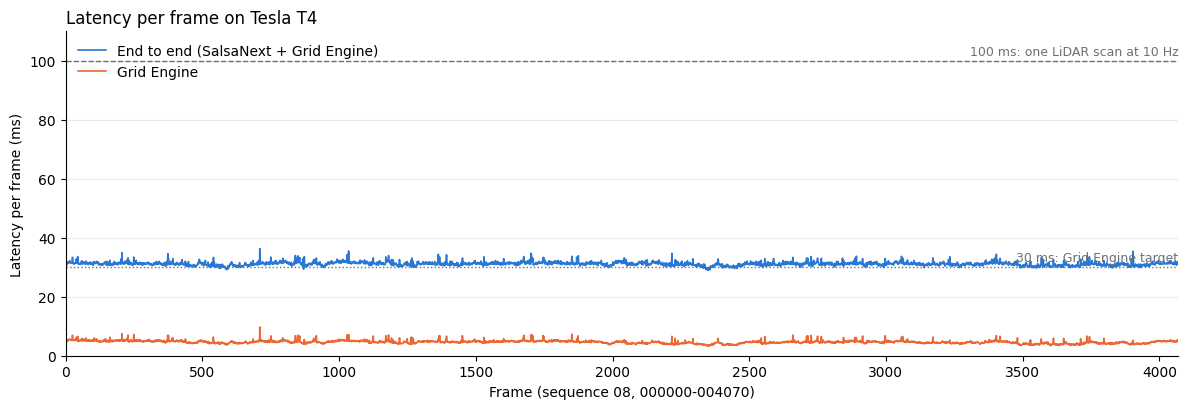

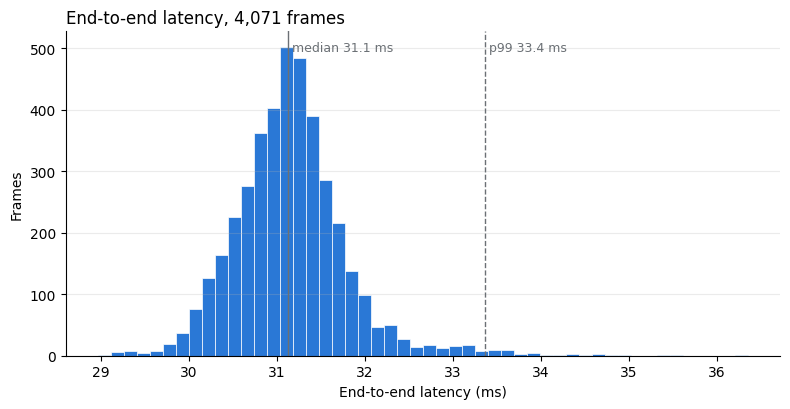

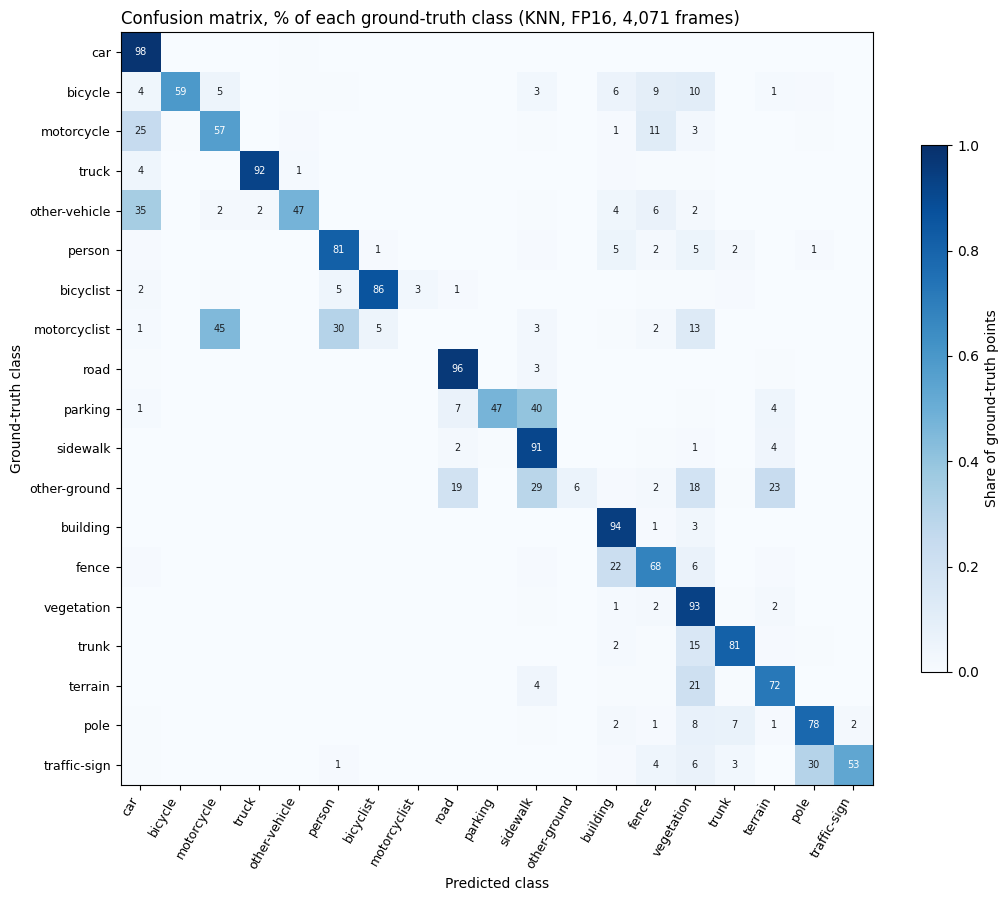

Charts saved in /kaggle/working/metrics


In [18]:
import matplotlib.pyplot as plt

BLUE, ORANGE, GREY = '#2a78d6', '#eb6834', '#6b7075'

def style(ax):
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.25)

# 1. Latency across the sequence
fig, ax = plt.subplots(figsize=(12, 4.2))
x = np.arange(len(df))
ax.plot(x, e2e.values, color=BLUE, lw=1.2, label='End to end (SalsaNext + Grid Engine)')
ax.plot(x, grid_t.values, color=ORANGE, lw=1.2, label='Grid Engine')
ax.axhline(100, color=GREY, ls='--', lw=1)
ax.axhline(30, color=GREY, ls=':', lw=1)
ax.text(len(df) - 1, 101, '100 ms: one LiDAR scan at 10 Hz', ha='right', va='bottom', color=GREY, fontsize=9)
ax.text(len(df) - 1, 31, '30 ms: Grid Engine target', ha='right', va='bottom', color=GREY, fontsize=9)
ax.set_ylim(0, max(110, e2e.max() * 1.1))
ax.set_xlim(0, max(len(df) - 1, 1))
ax.set_xlabel(f'Frame (sequence {SEQ}, {df.index[0]}-{df.index[-1]})')
ax.set_ylabel('Latency per frame (ms)')
ax.set_title(f'Latency per frame on {torch.cuda.get_device_name(0)}', loc='left')
ax.legend(loc='upper left', frameon=False)
style(ax)
fig.tight_layout()
fig.savefig(os.path.join(METRICS_DIR, 'latency_over_sequence.png'), dpi=150)
plt.show()

# 2. Latency histogram
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(e2e.values, bins=50, color=BLUE, edgecolor='white', linewidth=0.5)
for q, label, ls in [(e2e.median(), 'median', '-'), (e2e.quantile(0.99), 'p99', '--')]:
    ax.axvline(q, color=GREY, ls=ls, lw=1)
    ax.text(q, ax.get_ylim()[1] * 0.97, f' {label} {q:.1f} ms', color=GREY, fontsize=9, va='top')
ax.set_xlabel('End-to-end latency (ms)')
ax.set_ylabel('Frames')
ax.set_title(f'End-to-end latency, {len(df):,} frames', loc='left')
style(ax)
fig.tight_layout()
fig.savefig(os.path.join(METRICS_DIR, 'latency_histogram.png'), dpi=150)
plt.show()

# 3. Confusion matrix (pipeline labels, rows = ground truth, row-normalised)
if 'cms' in dir():
    cm = cms[active][1:, 1:].double().cpu().numpy()
    rows_present = cm.sum(1) > 0
    cm_n = cm[rows_present] / cm[rows_present].sum(1, keepdims=True)
    names_all = [GC.LABEL_NAMES[c] for c in range(1, NCLASSES)]
    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(names_all)), names_all, rotation=60, ha='right', fontsize=9)
    ax.set_yticks(range(int(rows_present.sum())), [n for n, p in zip(names_all, rows_present) if p], fontsize=9)
    for i in range(cm_n.shape[0]):
        for j in range(cm_n.shape[1]):
            if cm_n[i, j] >= 0.01:
                ax.text(j, i, f'{cm_n[i, j] * 100:.0f}', ha='center', va='center', fontsize=7,
                        color='white' if cm_n[i, j] > 0.5 else '#1b1f23')
    ax.set_xlabel('Predicted class')
    ax.set_ylabel('Ground-truth class')
    ax.set_title(f'Confusion matrix, % of each ground-truth class ({active}, {n_done:,} frames)', loc='left')
    fig.colorbar(im, ax=ax, shrink=0.7, label='Share of ground-truth points')
    fig.tight_layout()
    fig.savefig(os.path.join(METRICS_DIR, 'confusion_matrix.png'), dpi=150)
    plt.show()

print("Charts saved in", METRICS_DIR)

## 10. Export frames for the dashboard

Each frame is saved as `<frame>.npz` with:

- `cells`: FINAL_DTYPE structured array, one row per grid cell
  (`x_min, x_max, y_min, y_max, x_center, y_center, resolution, level, elevation, min_height, max_height,
  elevation_variance, semantic_class, semantic_confidence, occupancy, terrain_complexity, traversability,
  point_count, semantic_priority, height_range`). Class IDs follow SalsaNext (1 = car ... 19 = traffic-sign).
- `grid_config`, `stats`: text (`repr` of a dict), read with `ast.literal_eval(str(npz['grid_config']))`.

Saving happens outside the latency timers.

In [19]:
RUN_EXPORT = False     # set True to write the N_FRAMES frames (about 1.9 MB each)
OUT_DIR = f'/kaggle/working/grid_frames_seq{SEQ}'

if RUN_EXPORT:
    from tqdm import tqdm
    os.makedirs(OUT_DIR, exist_ok=True)
    for f in tqdm(BIN_FILES, desc="Grid export"):
        frame = os.path.basename(f)[:-4]
        res, cells, _ = run_frame(torch.from_numpy(load_scan(f)).cuda())
        export_frame(os.path.join(OUT_DIR, frame + '.npz'), cells, res.grid_config(), res.stats, frame)
    print("saved", len(os.listdir(OUT_DIR)), "frames to", OUT_DIR)
else:
    print("Export skipped (RUN_EXPORT = False)")

Export skipped (RUN_EXPORT = False)


## 11. Look at one frame

{'n_points_in': 123389, 'n_points_used': 123389, 'n_stage1_cells': 62468, 'n_splits': 1735, 'n_merges': 16577, 'n_final_cells': 51520, 'n_unlabeled_dropped': 0}
retention 100.00% | cells per size: {'5 cm': 28015, '10 cm': 4383, '20 cm': 13877, '40 cm': 5245}


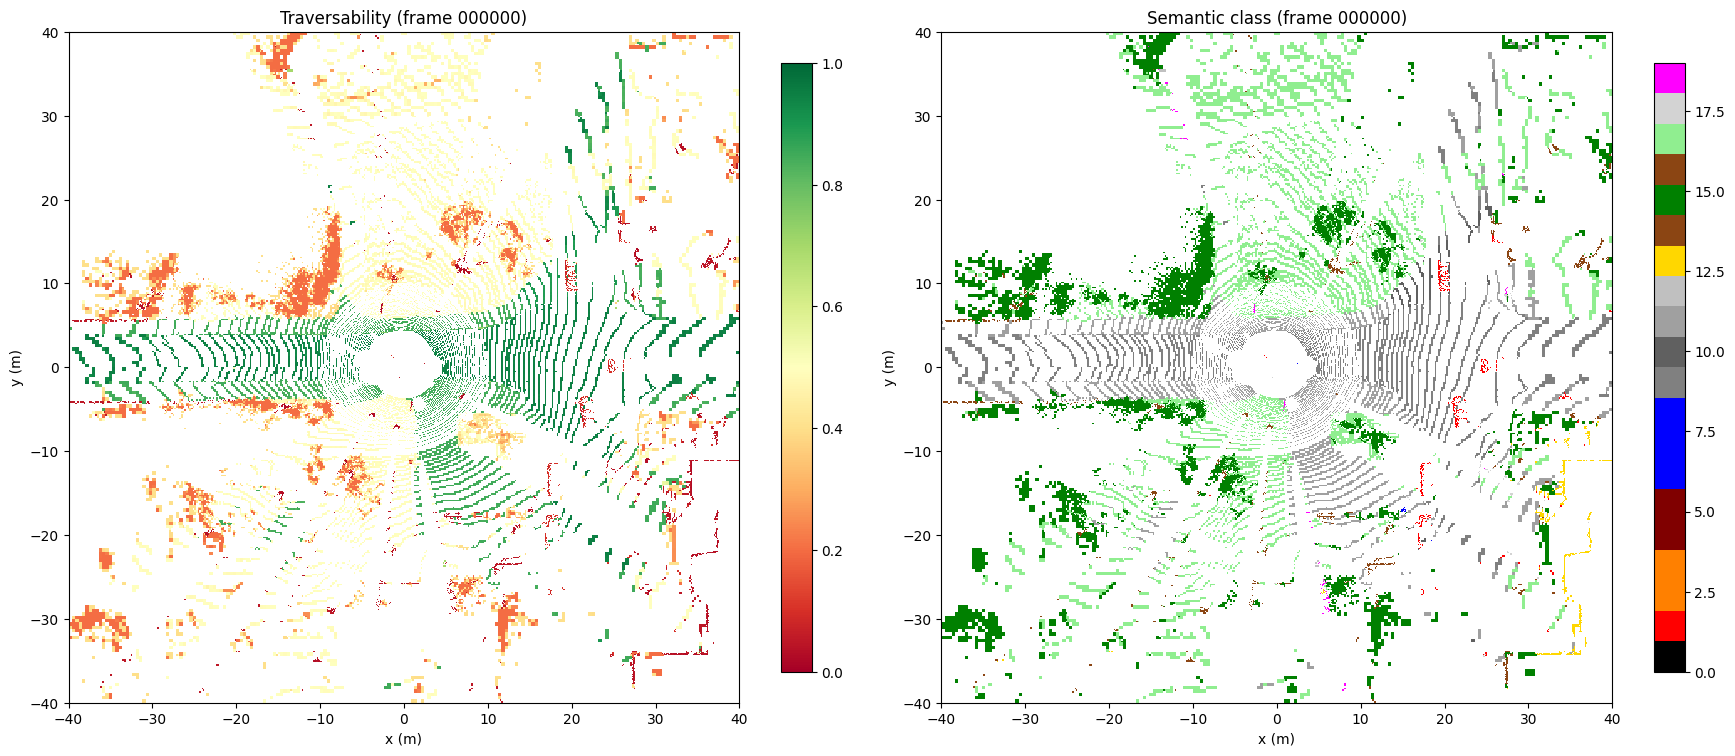

In [20]:
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.colors import ListedColormap

res, cells, _ = run_frame(torch.from_numpy(load_scan(BIN_FILES[0])).cuda())
print(res.stats)
print(f"retention {cells['point_count'].sum() / res.stats['n_points_used'] * 100:.2f}% | cells per size:",
      {f"{r * 100:g} cm": int((cells['resolution'] == r).sum()) for r in sorted(set(cells['resolution']))})

view = 40.0   # metres around the vehicle
c = cells[(np.abs(cells['x_center']) < view) & (np.abs(cells['y_center']) < view)]
verts = np.stack([np.stack([c['x_min'], c['y_min']], 1), np.stack([c['x_max'], c['y_min']], 1),
                  np.stack([c['x_max'], c['y_max']], 1), np.stack([c['x_min'], c['y_max']], 1)], 1)
class_cmap = ListedColormap([GC.CLASS_COLORS[i] for i in range(GC.N_CLASSES)])

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
for ax, values, cmap, title, vmin, vmax in [
        (axes[0], c['traversability'], 'RdYlGn', 'Traversability', 0, 1),
        (axes[1], c['semantic_class'], class_cmap, 'Semantic class', 0, GC.N_CLASSES - 1)]:
    pc = PolyCollection(verts, array=values, cmap=cmap, edgecolors='none')
    pc.set_clim(vmin, vmax)
    ax.add_collection(pc)
    ax.set_xlim(-view, view); ax.set_ylim(-view, view); ax.set_aspect('equal')
    ax.set_title(f"{title} (frame {os.path.basename(BIN_FILES[0])[:-4]})")
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
    fig.colorbar(pc, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()